This notebook is to gather indivudual results from the comet log file for different scenarios for all methods.

In [21]:
import sys
from comet_ml import API, Experiment
sys.path.append(".")

from utils import *

In [3]:
api = API(api_key="V1x7OI9PoIRM8yze4prM2FPcE")  # Replace with your actual Comet API key

In [4]:
workspace = "b-acharya"  # Replace with your Comet workspace name

#this is different for each project
project_name = "strat-exp1"  # Replace with your project name


In [5]:
experiments = api.get_experiments(workspace=workspace, project_name=project_name)

In [6]:
len(experiments)

334

# CMBP

In [7]:
#COHFACE and differnt models

CMBP_tscan_experiments = []
CMBP_deepphys_experiments = []
CMBP_rppgnet_experiments = []
CMBP_physnet_experiments = []

for experiment in experiments:
    print(f"Experiment Name: {experiment.name}")
    experiment_name = experiment.name

    if "CMBP" in experiment_name and "Tscan" in experiment_name:
        if "arxiv" in experiment.get_tags():
            CMBP_tscan_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "DeepPhys" in experiment_name:
        if "arxiv" in experiment.get_tags():
            CMBP_deepphys_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "Physnet" in experiment_name:
        CMBP_physnet_experiments.append(experiment)
        continue

    elif "CMBP" in experiment_name and "rPPGNet" in experiment_name:
        CMBP_rppgnet_experiments.append(experiment)
        continue

Experiment Name: CMBP_DeepPhys_FOLD_0
Experiment Name: CMBP_DeepPhys_FOLD_1
Experiment Name: CMBP_DeepPhys_FOLD_2
Experiment Name: CMBP_DeepPhys_FOLD_3
Experiment Name: CMBP_DeepPhys_FOLD_4
Experiment Name: CMBP_DeepPhys_FOLD_5
Experiment Name: CMBP_DeepPhys_FOLD_6
Experiment Name: CMBP_DeepPhys_FOLD_7
Experiment Name: CMBP_DeepPhys_FOLD_8
Experiment Name: CMBP_DeepPhys_FOLD_9
Experiment Name: CMBP_DeepPhys_FOLD_0
Experiment Name: CMBP_DeepPhys_FOLD_1
Experiment Name: CMBP_DeepPhys_FOLD_2
Experiment Name: CMBP_DeepPhys_FOLD_3
Experiment Name: CMBP_DeepPhys_FOLD_4
Experiment Name: CMBP_DeepPhys_FOLD_5
Experiment Name: CMBP_DeepPhys_FOLD_6
Experiment Name: CMBP_DeepPhys_FOLD_7
Experiment Name: CMBP_DeepPhys_FOLD_8
Experiment Name: CMBP_DeepPhys_FOLD_9
Experiment Name: PURE_DeepPhys_FOLD_0
Experiment Name: PURE_DeepPhys_FOLD_1
Experiment Name: PURE_DeepPhys_FOLD_2
Experiment Name: COHFACE_DeepPhys_FOLD_0
Experiment Name: PURE_DeepPhys_FOLD_3
Experiment Name: COHFACE_DeepPhys_FOLD_1
Experi

In [8]:
len(CMBP_tscan_experiments), len(CMBP_deepphys_experiments), len(CMBP_rppgnet_experiments), len(CMBP_physnet_experiments)

(10, 10, 10, 10)

In [9]:
deepPhys_CMBP_df = get_dataframe(CMBP_deepphys_experiments)

tscan_CMBP_df = get_dataframe(CMBP_tscan_experiments)

physnet_CMBP_df = get_dataframe(CMBP_physnet_experiments)

rppgnet_CMBP_df = get_dataframe(CMBP_rppgnet_experiments)


In [10]:
len(deepPhys_CMBP_df), len(rppgnet_CMBP_df), len(tscan_CMBP_df), len(physnet_CMBP_df)

(180, 180, 180, 180)

In [11]:

fold_CMBP_mae_deepphys_df = deepPhys_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_tscan_df = tscan_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_physnet_df = physnet_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_rppgnet_df = rppgnet_CMBP_df.groupby('FOLD')['Error'].mean()

print(fold_CMBP_mae_deepphys_df.mean())
print(fold_CMBP_mae_tscan_df.mean())
print(fold_CMBP_mae_physnet_df.mean())
print(fold_CMBP_mae_rppgnet_df.mean())

9.1058349609375
3.19061279296875
4.11712646484375
2.01324462890625


In [12]:
def modify_datafram_CMBP(df):
    df.reset_index(inplace=True)
    df['scenario'] = df['Participant-ID'].str[-1:].astype(int)
    df['Participant'] = df['Participant-ID'].str[2:-2]
    return df

deepPhys_CMBP_df = modify_datafram_CMBP(deepPhys_CMBP_df)
tscan_CMBP_df = modify_datafram_CMBP(tscan_CMBP_df)
physnet_CMBP_df = modify_datafram_CMBP(physnet_CMBP_df)
rppgnet_CMBP_df = modify_datafram_CMBP(rppgnet_CMBP_df)

deepPhys
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


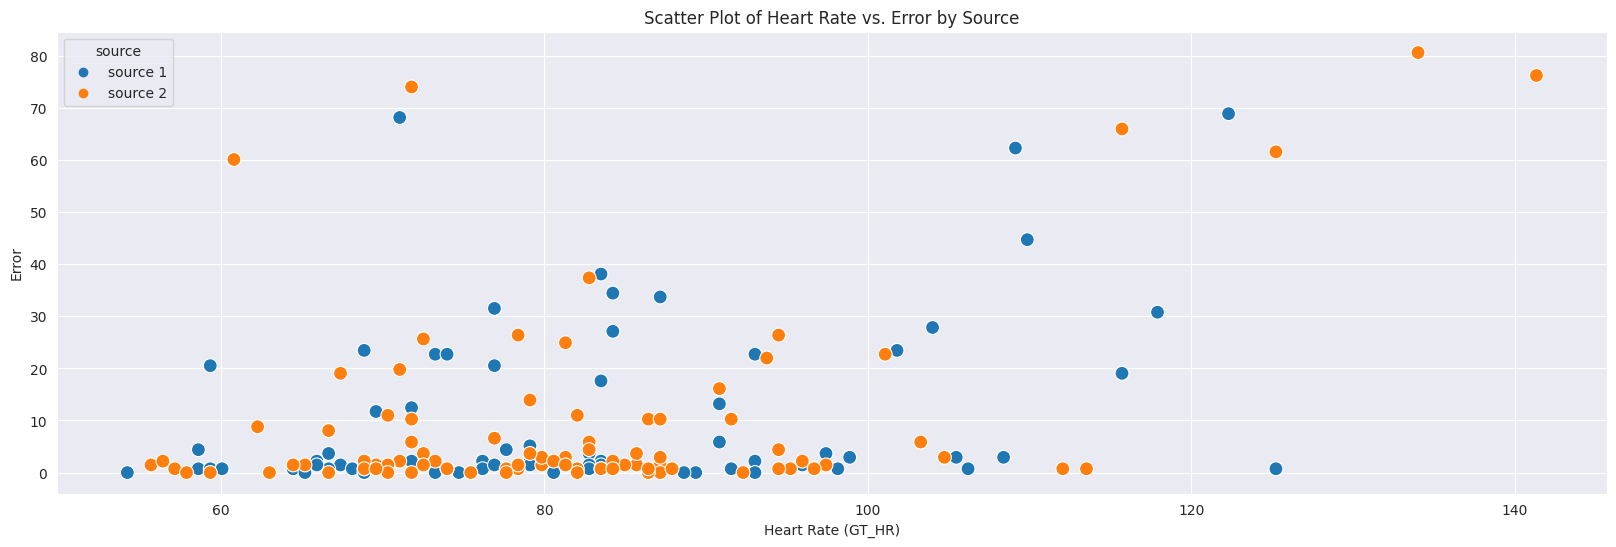

No. of Participants in dataset:  45


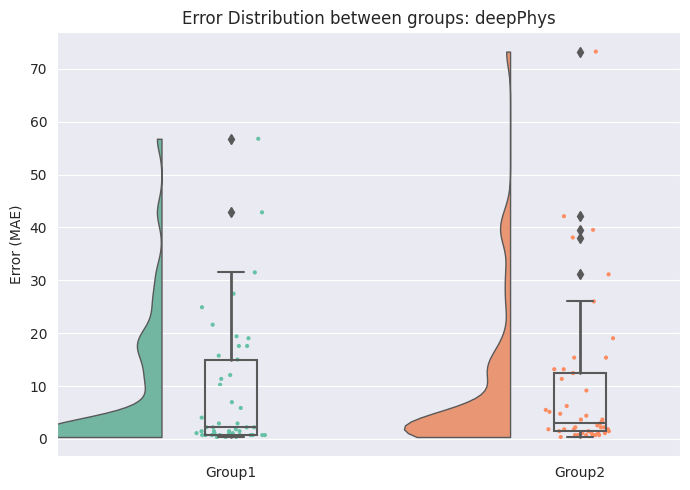

No significant difference detected between scenarios.
tscan
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


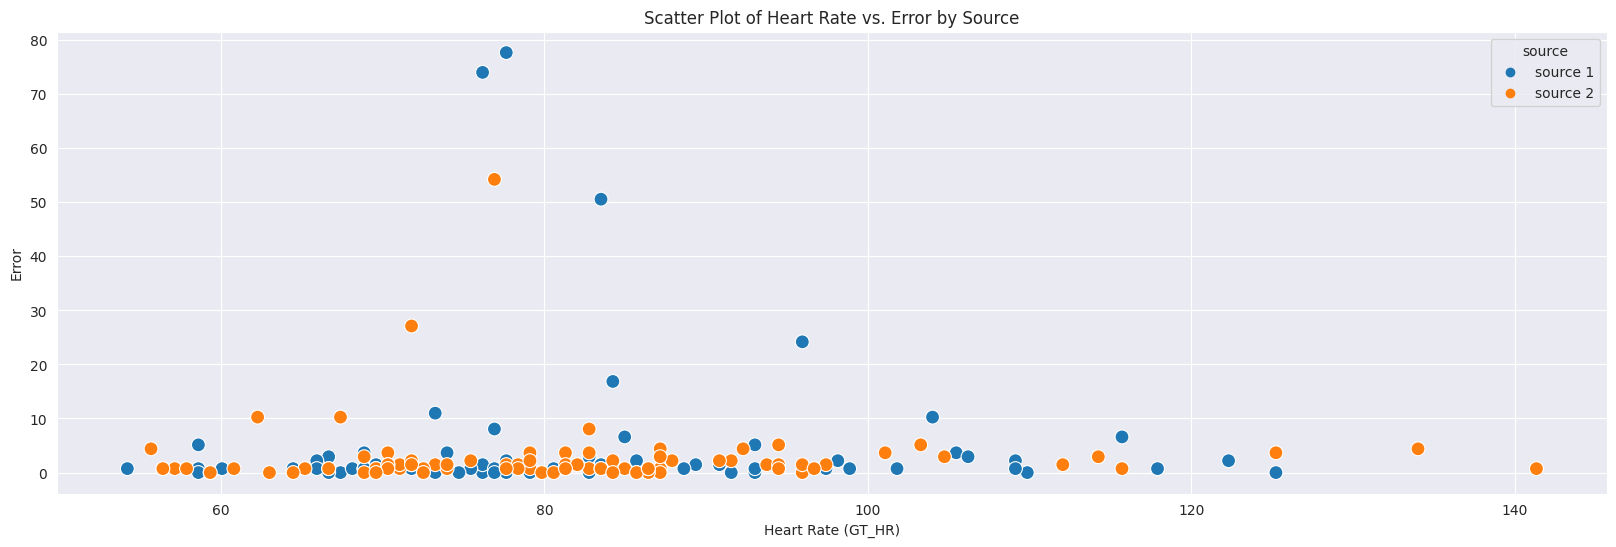

No. of Participants in dataset:  45


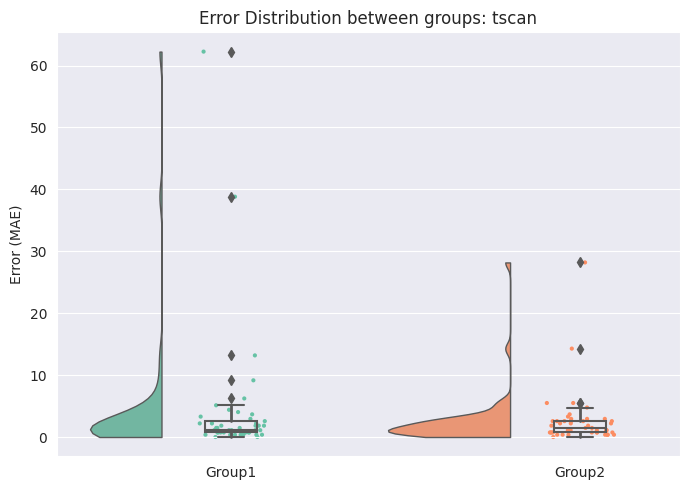

No significant difference detected between scenarios.
physnet
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


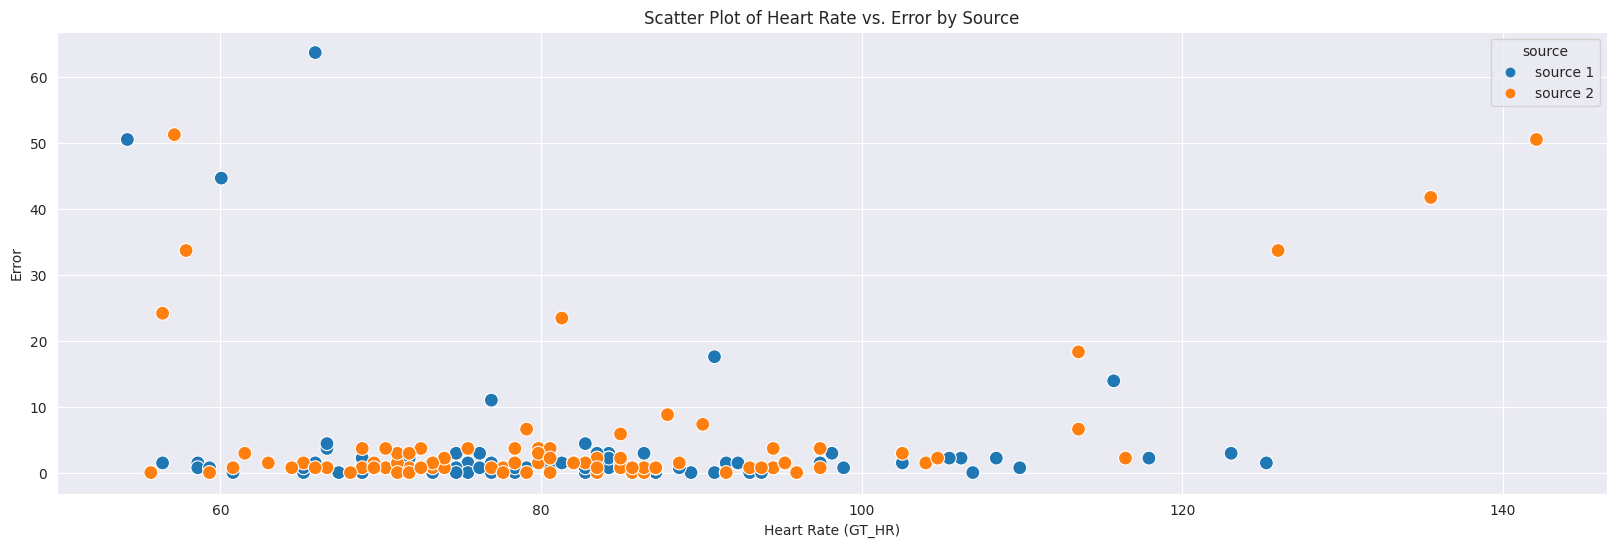

No. of Participants in dataset:  45


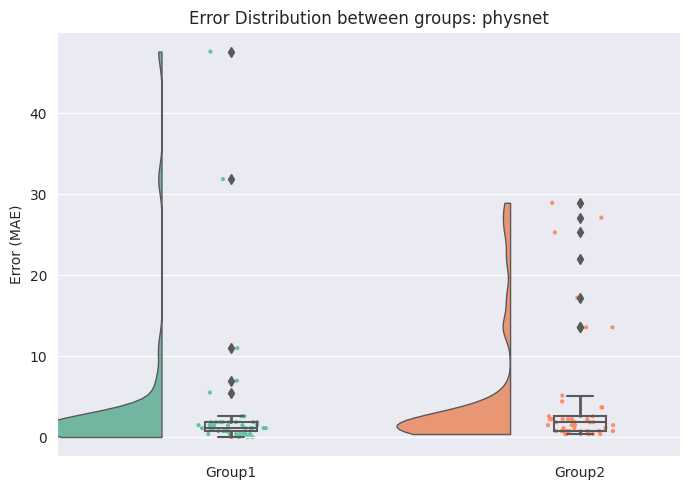

No significant difference detected between scenarios.
rppgnet
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


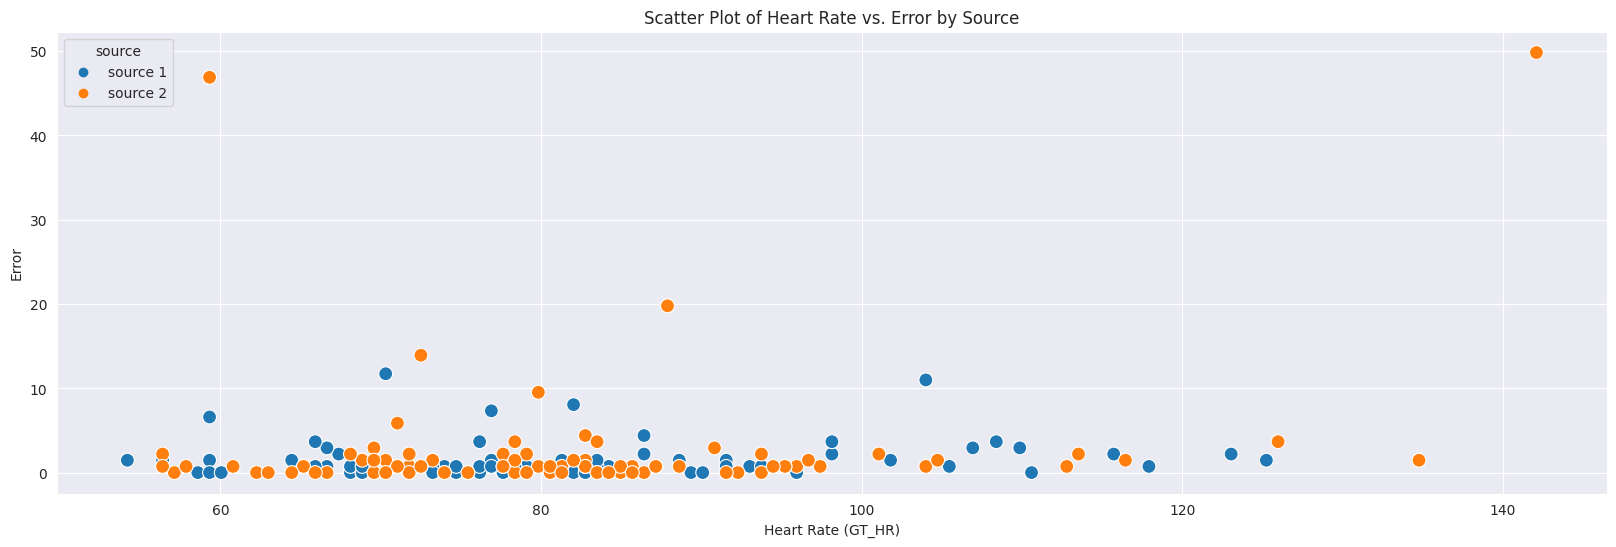

No. of Participants in dataset:  45


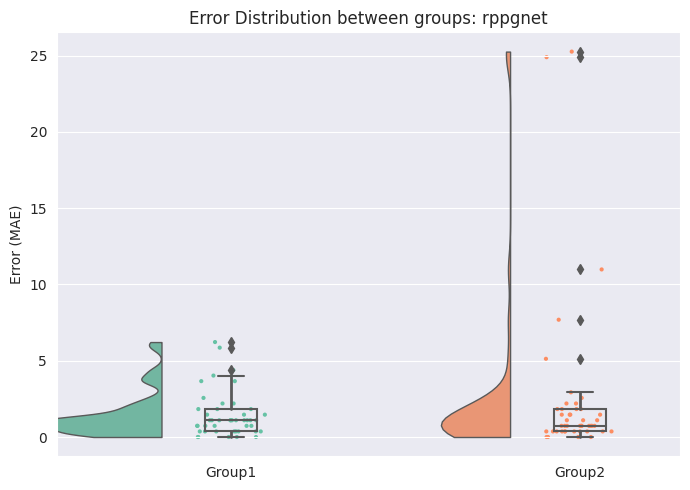

No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,deepPhys,Wilcoxon Signed-Rank Test,466.0,0.932612,-0.086656,2.197266,2.929688,-0.732422
1,tscan,Wilcoxon Signed-Rank Test,373.5,0.621526,-0.242301,1.098633,1.464844,-0.366211
2,physnet,Wilcoxon Signed-Rank Test,301.0,0.091961,-0.364293,1.098633,1.831055,-0.732422
3,rppgnet,Wilcoxon Signed-Rank Test,385.0,0.735101,-0.222951,1.098633,0.732422,0.366211


In [22]:

models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CMBP = []
dataset = "CHILL"

for model, model_name in zip(models, model_names):

    print(model_name)
    chill_statistical_tests = statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_illumination_groups(plot=True))

results_df = pd.DataFrame(results_CMBP)
results_df

In [24]:
import utils
from importlib import reload
reload(utils)
from utils import *

Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


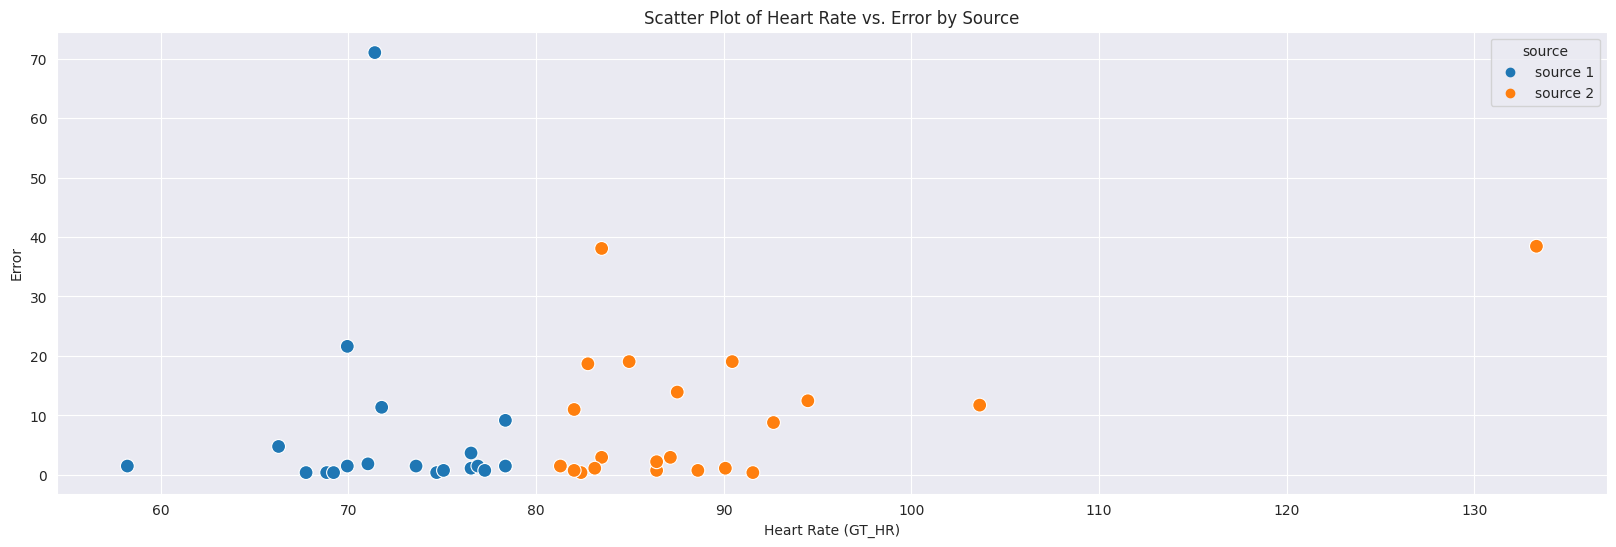

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


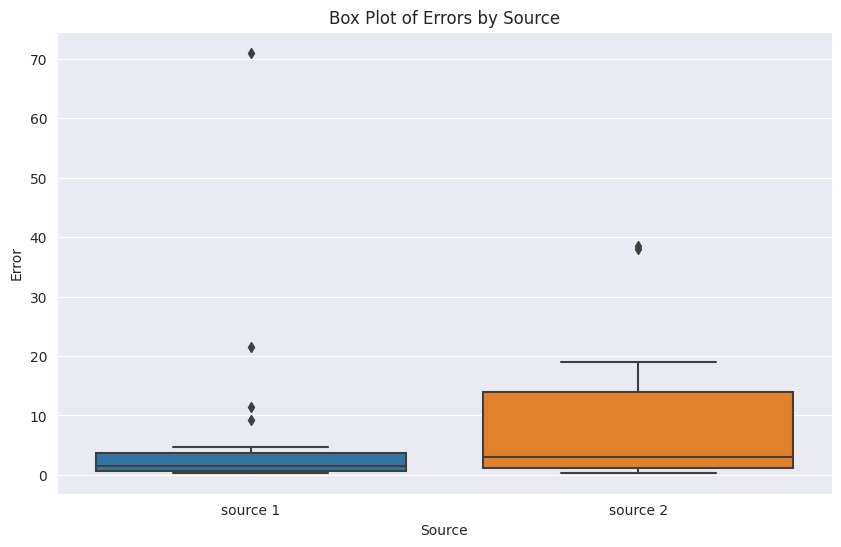

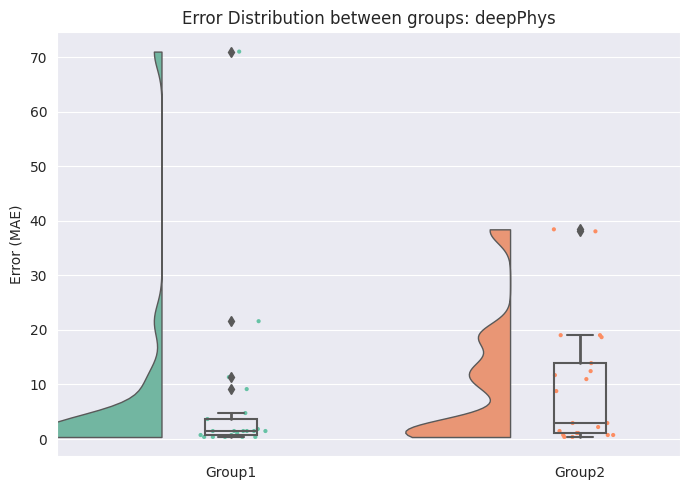

No significant difference detected between scenarios.
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


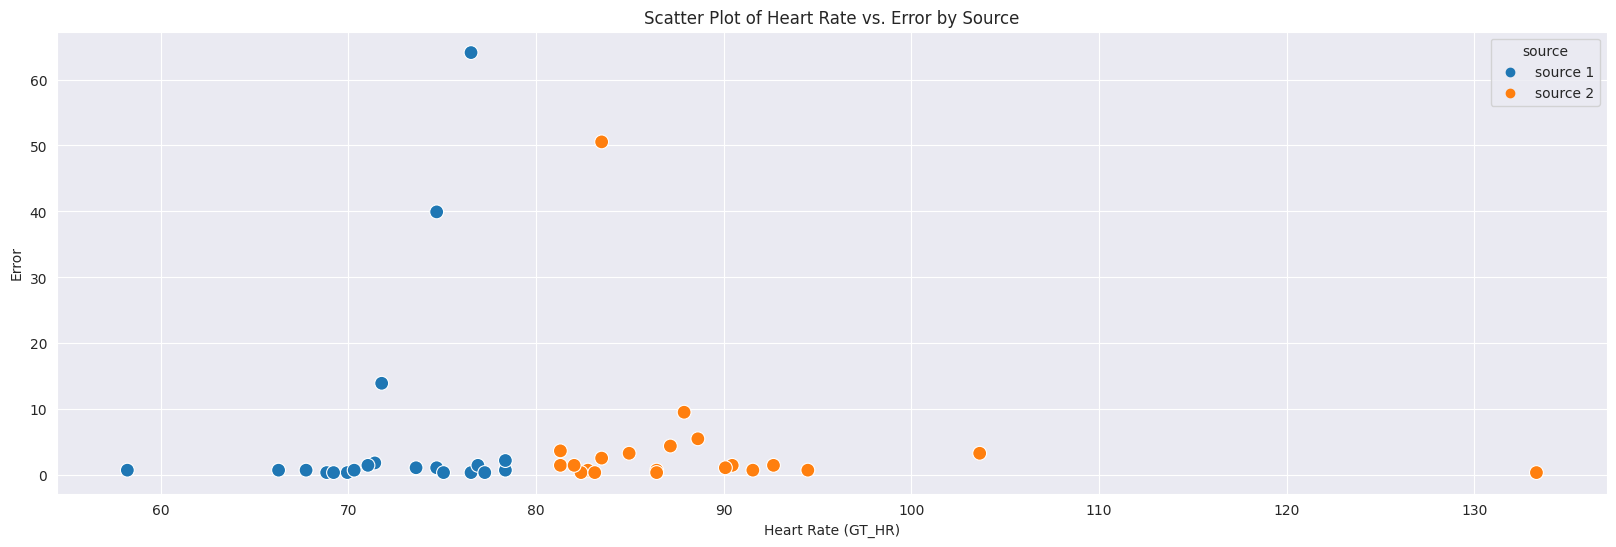

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


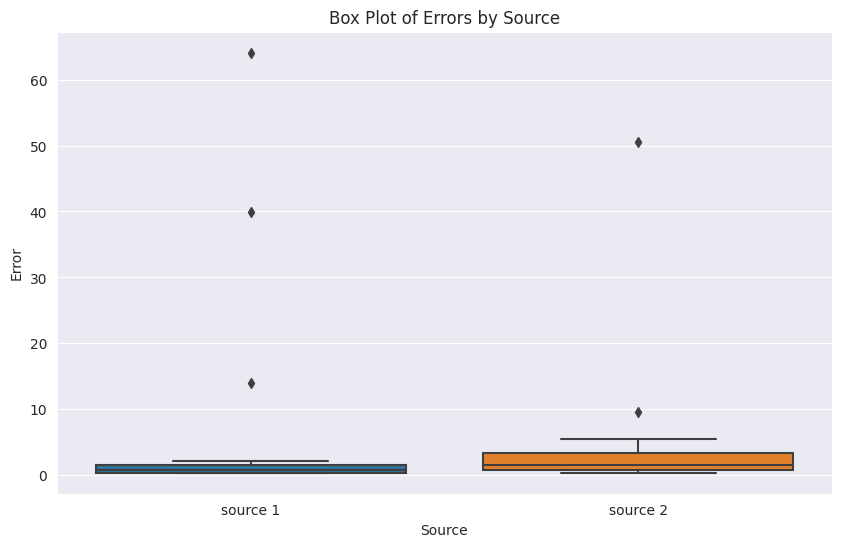

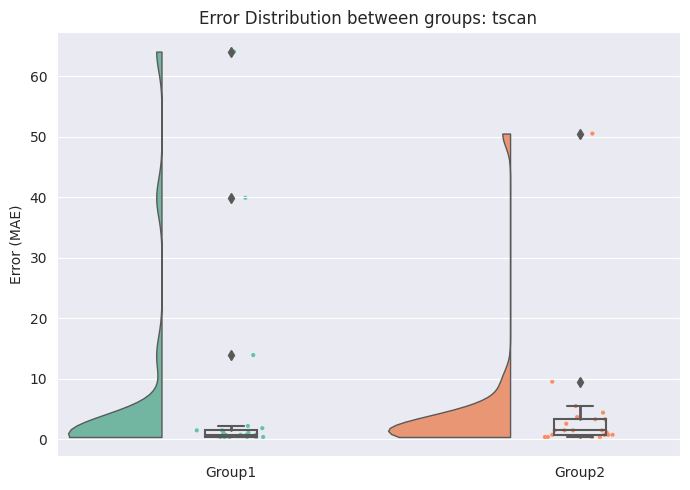

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


No significant difference detected between scenarios.
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


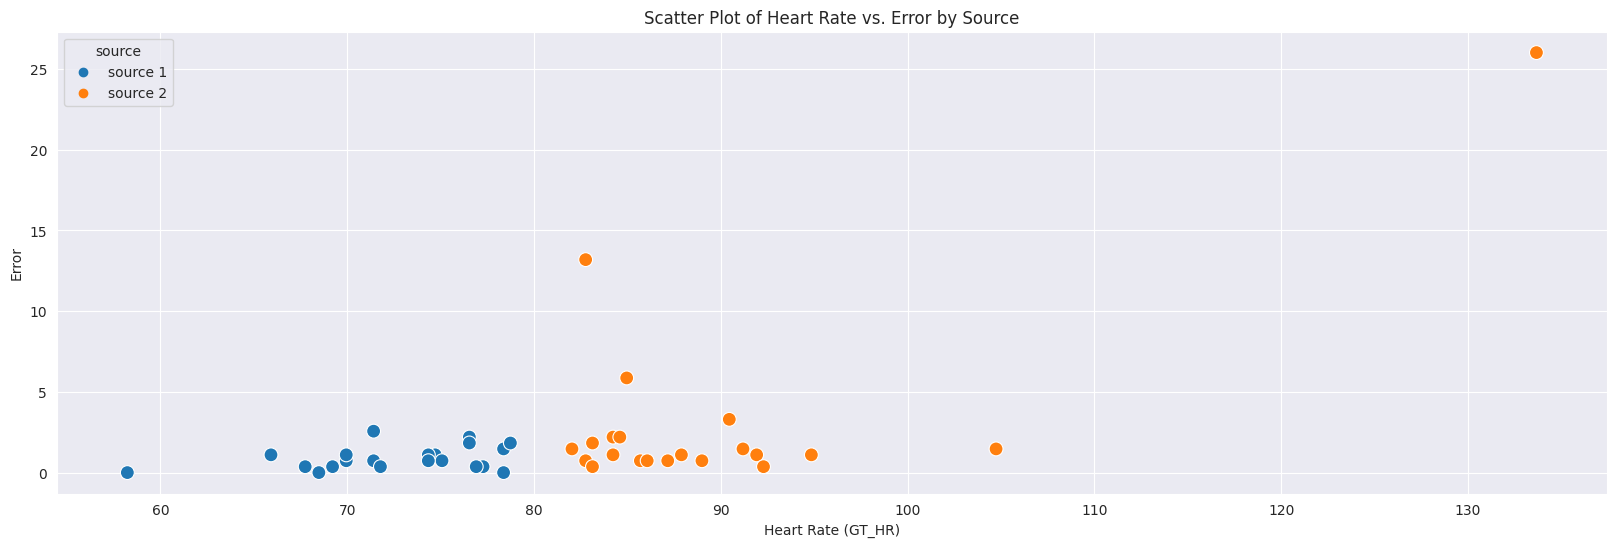

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


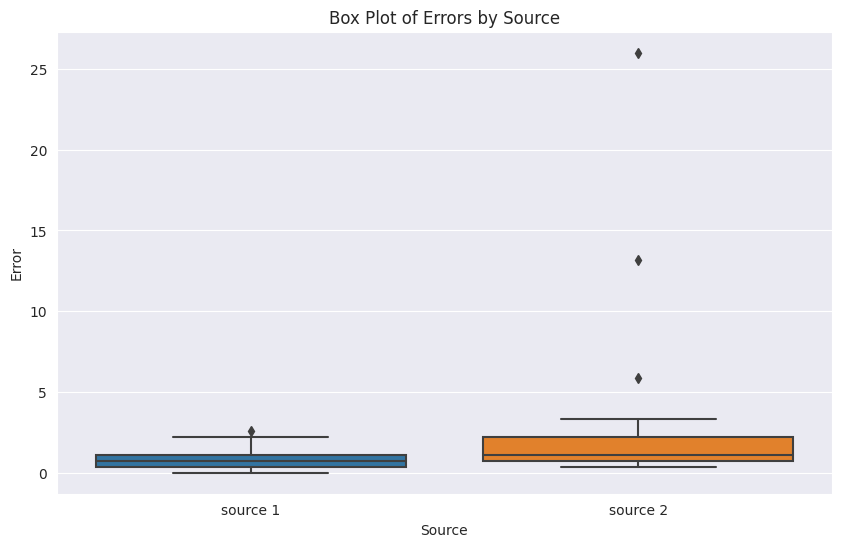

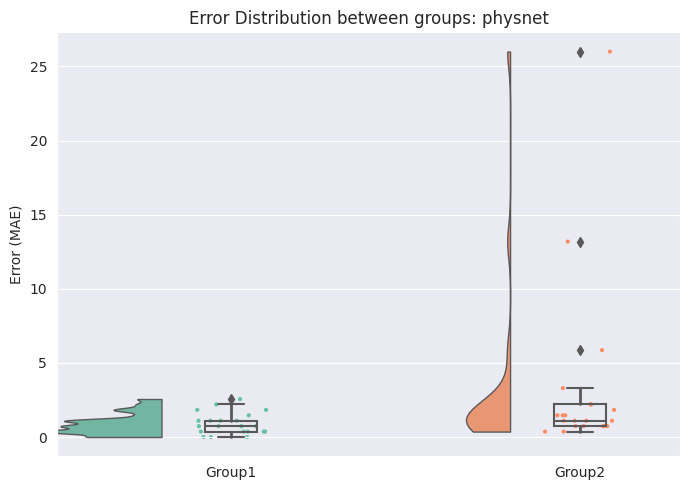

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


Significant difference detected between scenarios!
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


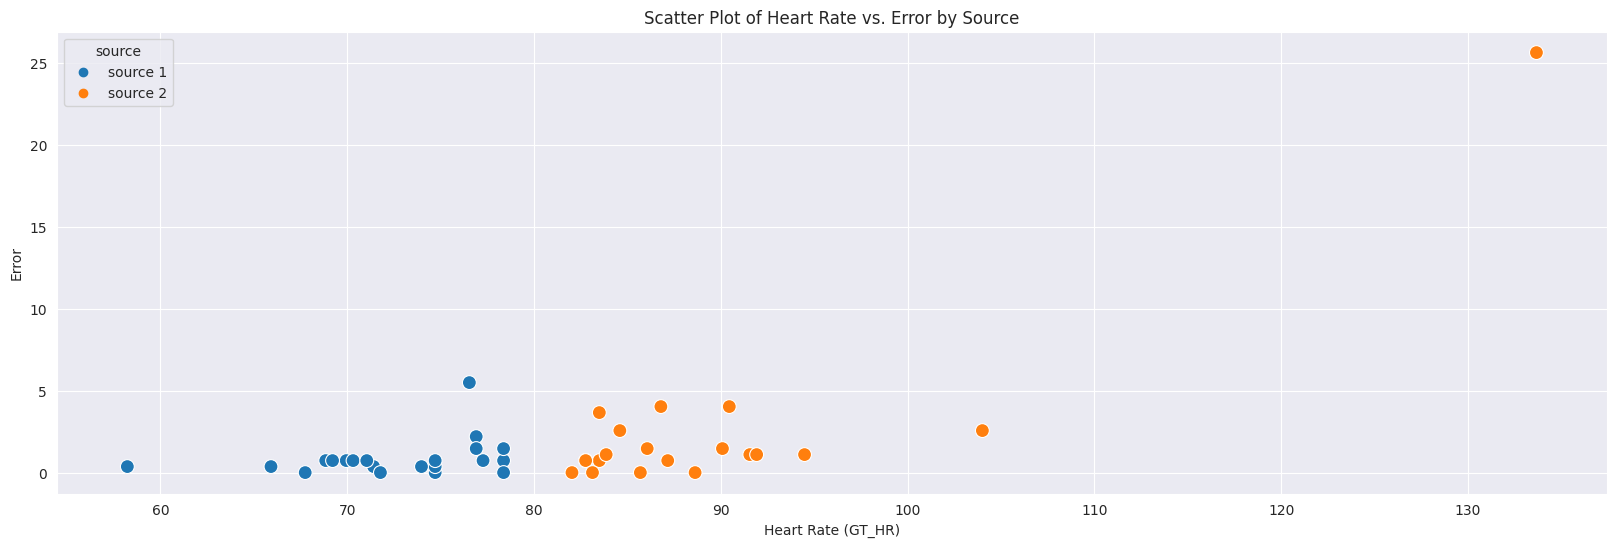

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


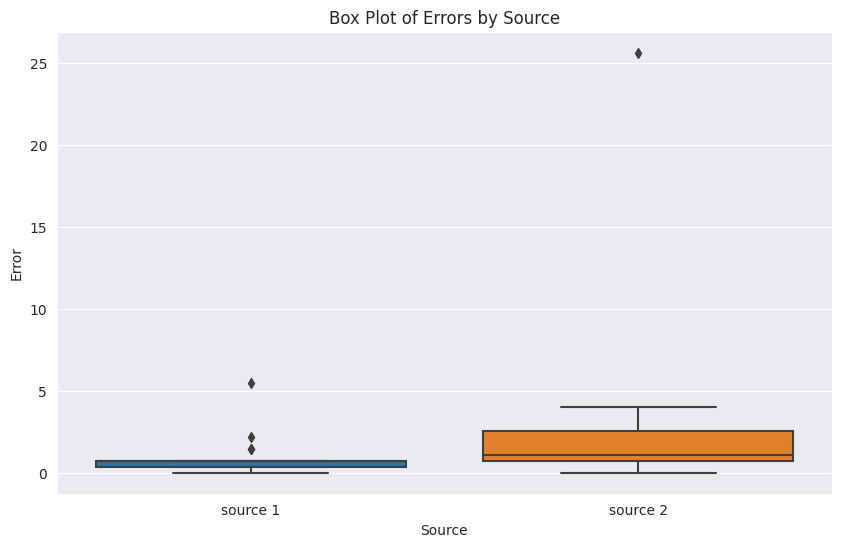

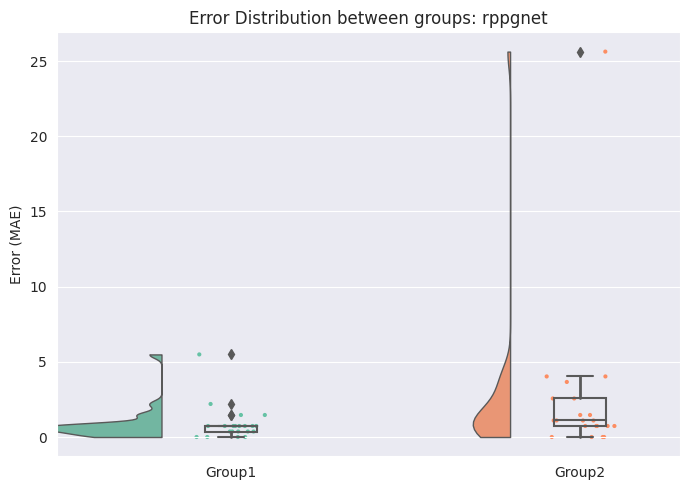

No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,deepPhys,Wilcoxon Signed-Rank Test,71.0,0.128078,-0.337521,1.464844,2.929688,-1.464844
1,tscan,Wilcoxon Signed-Rank Test,53.0,0.436738,-0.474046,0.732422,1.464844,-0.732422
2,physnet,Wilcoxon Signed-Rank Test,26.0,0.016365,-0.678834,0.732422,1.098633,-0.366211
3,rppgnet,Wilcoxon Signed-Rank Test,65.0,0.082195,-0.383029,0.732422,1.098633,-0.366211


In [46]:
models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CMBP = []
dataset = "CHILL"

for model, model_name in zip(models, model_names):

    chill_statistical_tests = utils.statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_hr_groups(plot=True))

results_df = pd.DataFrame(results_CMBP)
results_df

deepPhys
Using CHILL dataset
Defining scenarios


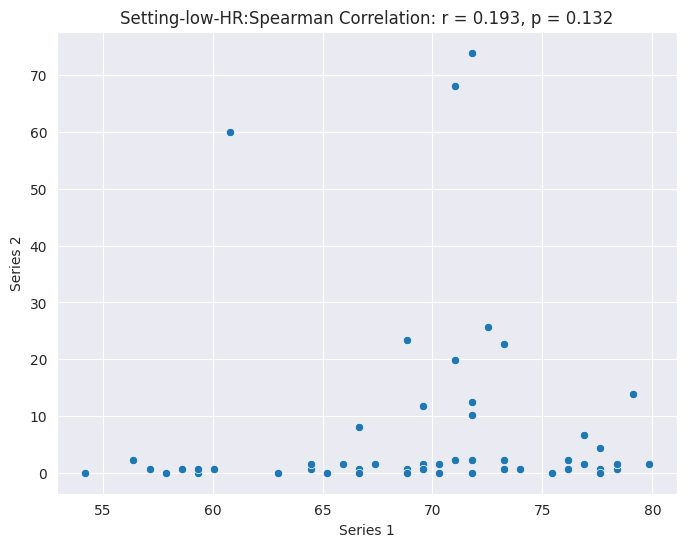

Using Spearman correlation:
Correlation coefficient (r): 0.193
P-value: 0.132
No significant correlation.


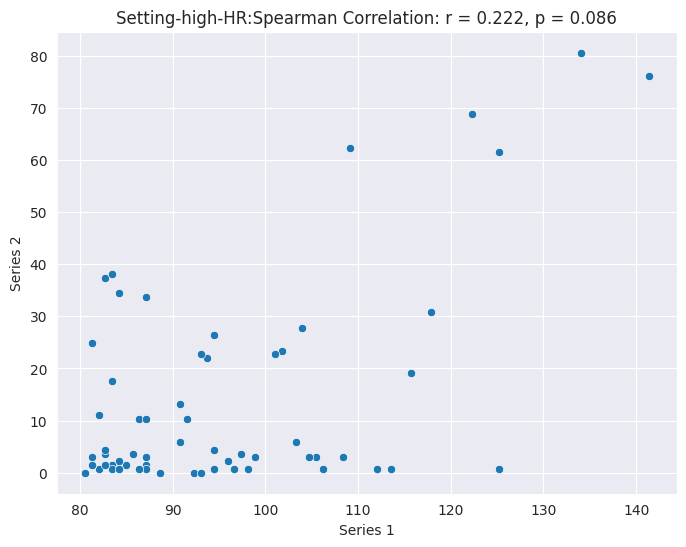

Using Spearman correlation:
Correlation coefficient (r): 0.222
P-value: 0.086
No significant correlation.
tscan
Using CHILL dataset
Defining scenarios


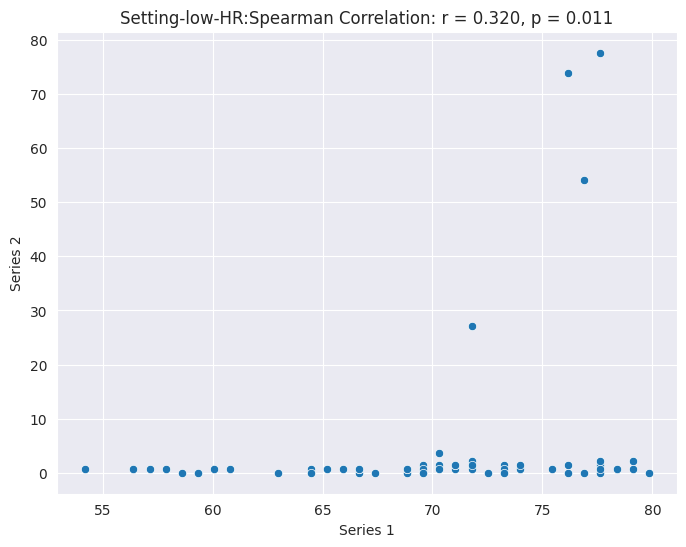

Using Spearman correlation:
Correlation coefficient (r): 0.320
P-value: 0.011
Significant correlation detected!


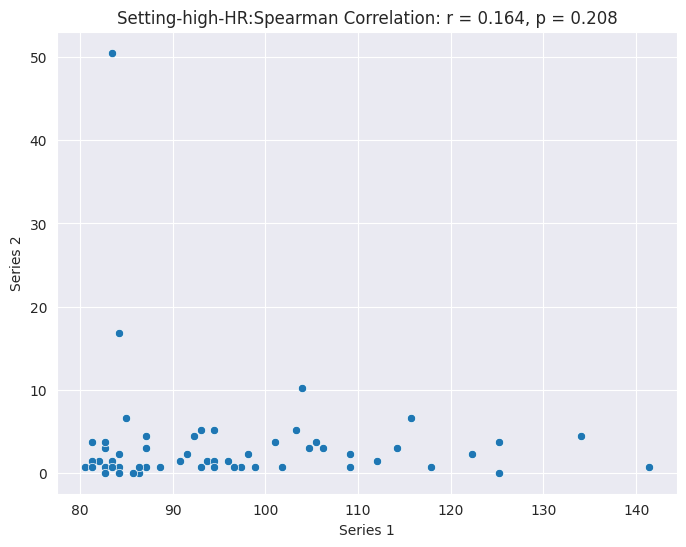

Using Spearman correlation:
Correlation coefficient (r): 0.164
P-value: 0.208
No significant correlation.
physnet
Using CHILL dataset
Defining scenarios


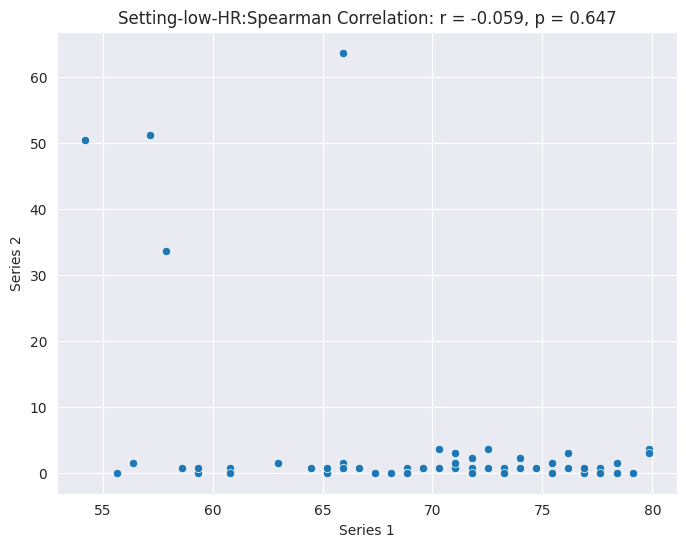

Using Spearman correlation:
Correlation coefficient (r): -0.059
P-value: 0.647
No significant correlation.


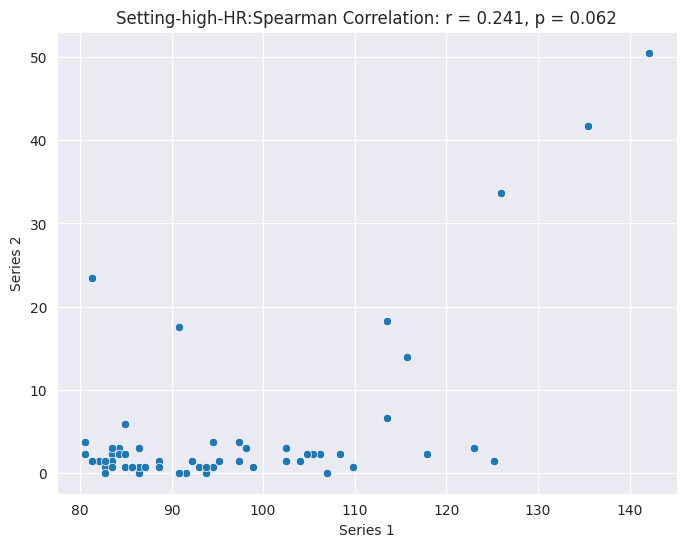

Using Spearman correlation:
Correlation coefficient (r): 0.241
P-value: 0.062
No significant correlation.
rppgnet
Using CHILL dataset
Defining scenarios


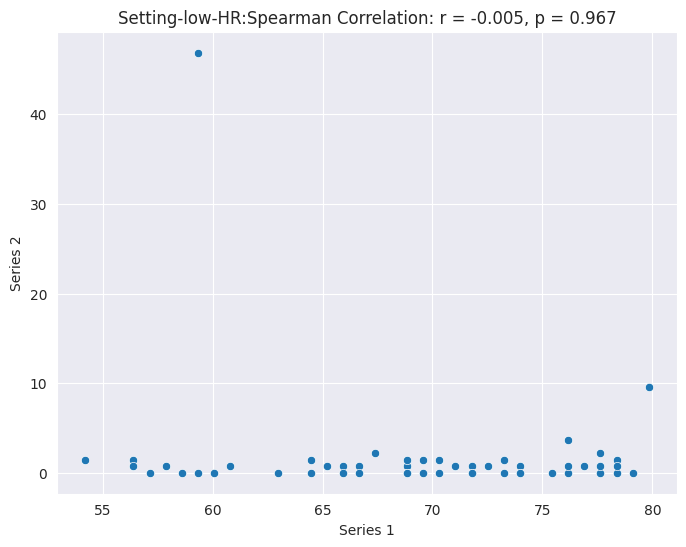

Using Spearman correlation:
Correlation coefficient (r): -0.005
P-value: 0.967
No significant correlation.


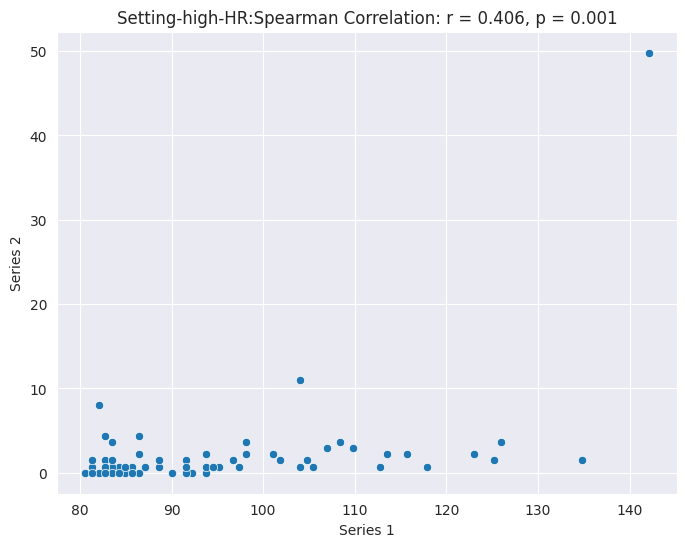

Using Spearman correlation:
Correlation coefficient (r): 0.406
P-value: 0.001
Significant correlation detected!


In [40]:
reload(utils)
models = [ deepPhys_CMBP_df, tscan_CMBP_df, physnet_CMBP_df, rppgnet_CMBP_df ]
model_names = ["deepPhys", "tscan", "physnet", "rppgnet"]

results_CHILL_LowHR = []
results_CHILL_HighHR = []
dataset = "CHILL"

for model, model_name in zip(models, model_names):
    print(model_name)
    chill_statistical_tests = utils.statistical_tests(model, model_name, dataset)
    lowhr_metrics, highhr_metrics = chill_statistical_tests.perform_spearman_correlation(debug=False)
    results_CHILL_LowHR.append(lowhr_metrics)
    results_CHILL_HighHR.append(highhr_metrics)

low_hr_df = pd.DataFrame(results_CHILL_LowHR)
high_hr_df = pd.DataFrame(results_CHILL_HighHR)
lowhr_df = pd.DataFrame()

In [16]:

low_hr_df

,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,spearman,spearman,0.193375,0.132091,0.0,0.0,0.0,0.0
1,spearman,spearman,0.319830,0.011276,0.0,0.0,0.0,0.0
2,spearman,spearman,-0.059308,0.647029,0.0,0.0,0.0,0.0
3,spearman,spearman,-0.005431,0.966583,0.0,0.0,0.0,0.0


In [17]:
high_hr_df

,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,spearman,spearman,0.221720,0.085922,0.0,0.0,0.0,0.0
1,spearman,spearman,0.163529,0.207931,0.0,0.0,0.0,0.0
2,spearman,spearman,0.240740,0.061633,0.0,0.0,0.0,0.0
3,spearman,spearman,0.406007,0.001168,0.0,0.0,0.0,0.0


# Classical methods on CMBP

In [27]:
workspace = "b-acharya"  # Replace with your Comet workspace name

#this is different for each project
project_name = "dst-dataset-unsupervised"  # Replace with your project name


In [28]:
experiments = api.get_experiments(workspace=workspace, project_name=project_name)

In [29]:
# Classical methods
#CMBP and differnt models 

CMBP_POS_experiments = []
CMBP_GREEN_experiments = []
CMBP_CHROM_experiments = []
CMBP_ICA_experiments = []

for experiment in experiments:
    print(f"Experiment Name: {experiment.name}")
    experiment_name = experiment.name
    
    if "POS" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_POS_experiments.append(experiment)
        
        continue
    
    elif "GREEN" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_GREEN_experiments.append(experiment)
        continue
    
    elif "ICA" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_ICA_experiments.append(experiment)
        continue
        
    elif "CHROM" in experiment_name:
        if "arxiv" in experiment.get_tags() and "CMBP" in experiment.get_tags():
            CMBP_CHROM_experiments.append(experiment)
        continue

Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: dummy
Experiment Name: random
Experiment Name: random
Experiment Name: Tscan_DST_
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: Tscan_DST_
Experiment Name: ICA
Experiment Name: POS
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment Name: dummy
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: ICA
Experiment Name: POS
Experiment Name: CHROM
Experiment Name: GREEN
Experiment Name: LGI
Experiment Name: PBV
Experiment 

In [30]:
POS_CMBP_df = get_dataframe(CMBP_POS_experiments)

GREEN_CMBP_df = get_dataframe(CMBP_GREEN_experiments)

ICA_CMBP_df = get_dataframe(CMBP_ICA_experiments)

CHROM_CMBP_df = get_dataframe(CMBP_CHROM_experiments)

In [31]:

len(POS_CMBP_df), len(CHROM_CMBP_df), len(GREEN_CMBP_df), len(ICA_CMBP_df)

fold_CMBP_mae_POS_df = POS_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_GREEN_df = GREEN_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_ICA_df = ICA_CMBP_df.groupby('FOLD')['Error'].mean()
fold_CMBP_mae_CHROM_df = CHROM_CMBP_df.groupby('FOLD')['Error'].mean()

print(fold_CMBP_mae_POS_df.mean())
print(fold_CMBP_mae_GREEN_df.mean())
print(fold_CMBP_mae_ICA_df.mean())
print(fold_CMBP_mae_CHROM_df.mean())


1.08642578125
2.60009765625
5.38330078125
1.7659505208333333


In [34]:


def modify_datafram_CMBP(df):
    df.reset_index(inplace=True)
    df['scenario'] = df['Participant-ID'].str[-1:].astype(int)
    df['Participant'] = df['Participant-ID'].str[:-2]
    return df

POS_CMBP_df = modify_datafram_CMBP(POS_CMBP_df)
GREEN_CMBP_df = modify_datafram_CMBP(GREEN_CMBP_df)
ICA_CMBP_df = modify_datafram_CMBP(ICA_CMBP_df)
CHROM_CMBP_df = modify_datafram_CMBP(CHROM_CMBP_df)

In [35]:
POS_CMBP_df

,level_0,index,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
0,0,0,S,AY31324245_0,84.228516,83.496094,0.732422,0,AY31324245
1,1,1,S,AY31324245_1,82.031250,81.298828,0.732422,1,AY31324245
2,2,2,S,AY31324245_2,80.566406,81.298828,0.732422,2,AY31324245
3,3,3,S,AY31324245_3,90.820312,88.623047,2.197266,3,AY31324245
4,4,4,S,CC36214245_0,109.863281,111.328125,1.464844,0,CC36214245
...,...,...,...,...,...,...,...,...,...
175,175,175,S,VM20214245_3,84.228516,83.496094,0.732422,3,VM20214245
176,176,176,S,VR35324245_0,68.847656,68.847656,0.000000,0,VR35324245
177,177,177,S,VR35324245_1,69.580078,69.580078,0.000000,1,VR35324245
178,178,178,S,VR35324245_2,82.763672,82.763672,0.000000,2,VR35324245


In [40]:
reload(utils)
models = [ POS_CMBP_df, GREEN_CMBP_df, ICA_CMBP_df, CHROM_CMBP_df]
model_names = ["POS", "GREEN", "ICA", "CHROM"]
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="Illumination", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df

Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31324245', 'NB31324245', 'GC34324245', 'HB21344245', 'AY31324245', 'CU34214245', 'NN30214245', 'MY37214245', 'HJ34324245', 'NY20214245', 'VI49324245', 'RD37214245', 'HI44214245', 'EY20214245', 'UG35324245', 'LG31214245', 'NU34214245', 'ND35324245', 'CJ48324245', 'VR35324245', 'LD31324245', 'OD35324245', 'IH29344245', 'CR42324245', 'Ec20214245', 'NJ20214245', 'PI34324245', 'OY31324245', 'NC33214245', 'CG43214245', 'ON20344245', 'LI36344245', 'KI35324245'}
Test Used: Wilcoxon signed-rank test
Test Used: 266.0
p-value: 0.41858
cohen_d: -0.00468
effect_size_r: -0.42319
No significant difference detected between scenarios.
Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31

,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,POS,Wilcoxon signed-rank test,266.0,0.419,-0.005,-0.423
1,GREEN,Wilcoxon signed-rank test,248.0,0.045,-0.251,-0.453
2,ICA,Wilcoxon signed-rank test,226.0,0.003,-0.413,-0.490
3,CHROM,Wilcoxon signed-rank test,361.5,0.688,-0.056,-0.262


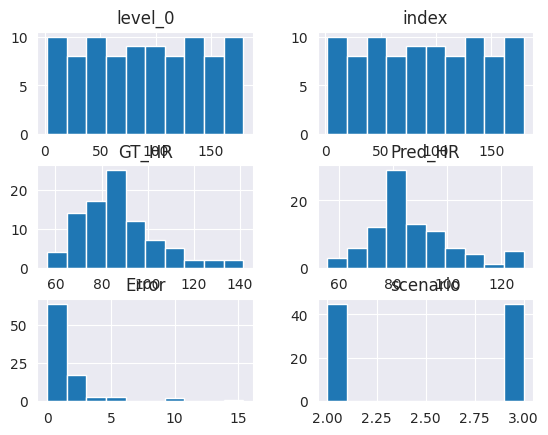

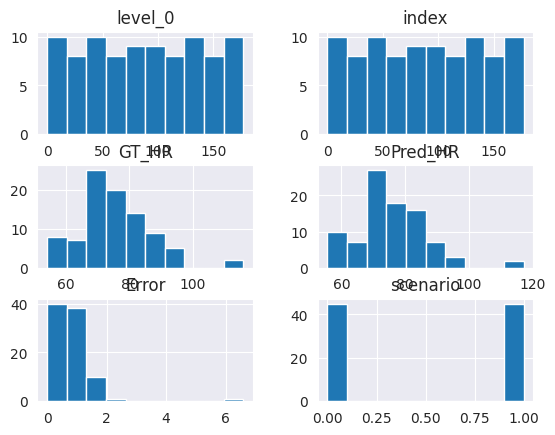

Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31324245', 'NB31324245', 'GC34324245', 'HB21344245', 'AY31324245', 'CU34214245', 'NN30214245', 'MY37214245', 'HJ34324245', 'NY20214245', 'VI49324245', 'RD37214245', 'HI44214245', 'EY20214245', 'UG35324245', 'LG31214245', 'NU34214245', 'ND35324245', 'CJ48324245', 'VR35324245', 'LD31324245', 'OD35324245', 'IH29344245', 'CR42324245', 'Ec20214245', 'NJ20214245', 'PI34324245', 'OY31324245', 'NC33214245', 'CG43214245', 'ON20344245', 'LI36344245', 'KI35324245'}
Test Used: Wilcoxon signed-rank test
Test Used: 103.0
p-value: 0.00003
cohen_d: 0.58600
effect_size_r: -0.69746
Significant difference detected between scenarios!


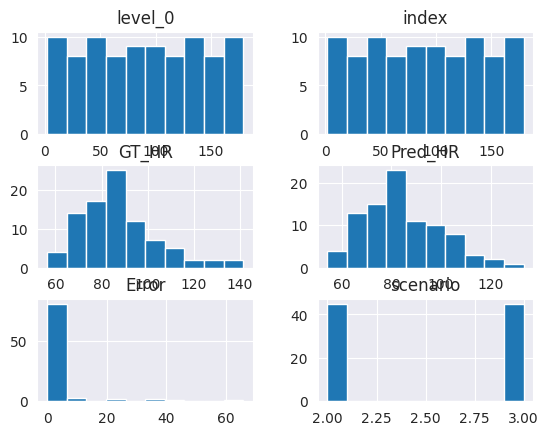

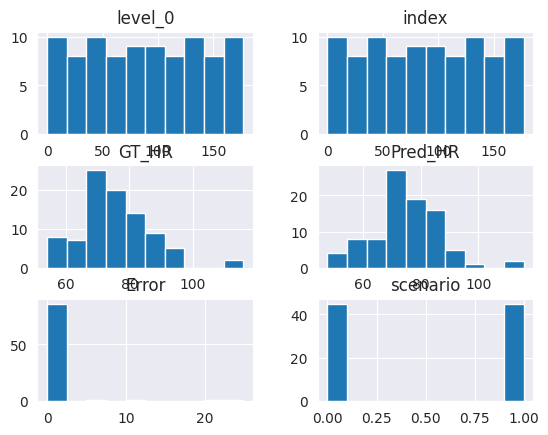

Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31324245', 'NB31324245', 'GC34324245', 'HB21344245', 'AY31324245', 'CU34214245', 'NN30214245', 'MY37214245', 'HJ34324245', 'NY20214245', 'VI49324245', 'RD37214245', 'HI44214245', 'EY20214245', 'UG35324245', 'LG31214245', 'NU34214245', 'ND35324245', 'CJ48324245', 'VR35324245', 'LD31324245', 'OD35324245', 'IH29344245', 'CR42324245', 'Ec20214245', 'NJ20214245', 'PI34324245', 'OY31324245', 'NC33214245', 'CG43214245', 'ON20344245', 'LI36344245', 'KI35324245'}
Test Used: Wilcoxon signed-rank test
Test Used: 136.0
p-value: 0.00022
cohen_d: 0.28128
effect_size_r: -0.64193
Significant difference detected between scenarios!


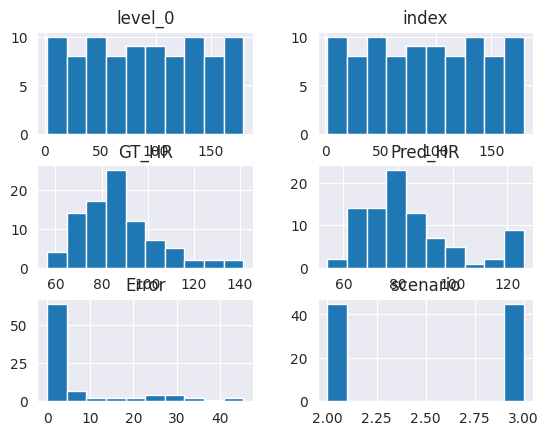

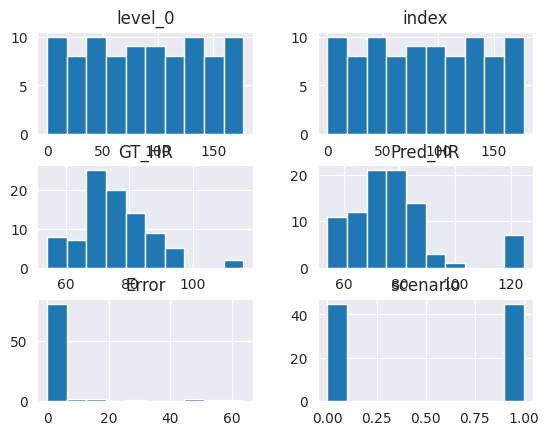

Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31324245', 'NB31324245', 'GC34324245', 'HB21344245', 'AY31324245', 'CU34214245', 'NN30214245', 'MY37214245', 'HJ34324245', 'NY20214245', 'VI49324245', 'RD37214245', 'HI44214245', 'EY20214245', 'UG35324245', 'LG31214245', 'NU34214245', 'ND35324245', 'CJ48324245', 'VR35324245', 'LD31324245', 'OD35324245', 'IH29344245', 'CR42324245', 'Ec20214245', 'NJ20214245', 'PI34324245', 'OY31324245', 'NC33214245', 'CG43214245', 'ON20344245', 'LI36344245', 'KI35324245'}
Test Used: Wilcoxon signed-rank test
Test Used: 231.5
p-value: 0.00350
cohen_d: 0.27466
effect_size_r: -0.48124
Significant difference detected between scenarios!


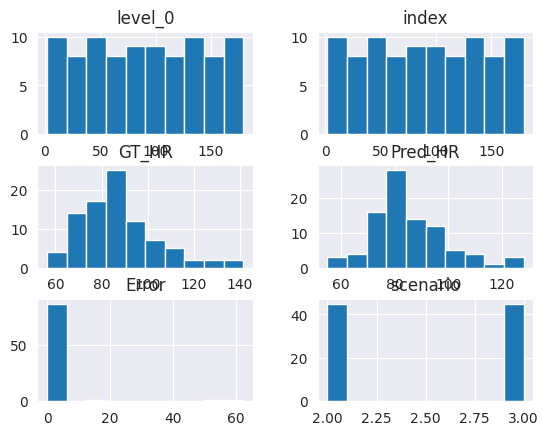

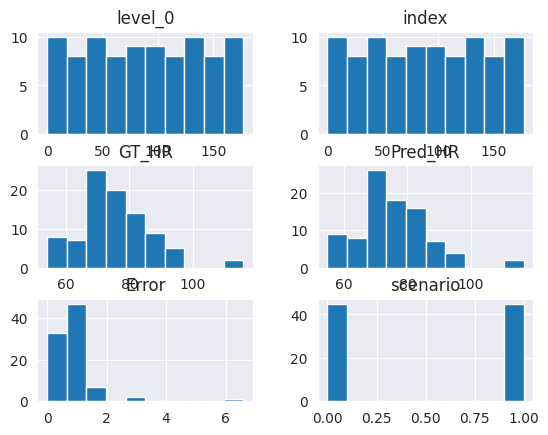

Participant : {'HD37214245', 'NP44214245', 'VL31214245', 'OD31324245', 'CC36214245', 'NT31214245', 'LI34344245', 'NN33214245', 'VM20214245', 'LU42324245', 'LY31324245', 'CC36344245', 'JD31324245', 'NB31324245', 'GC34324245', 'HB21344245', 'AY31324245', 'CU34214245', 'NN30214245', 'MY37214245', 'HJ34324245', 'NY20214245', 'VI49324245', 'RD37214245', 'HI44214245', 'EY20214245', 'UG35324245', 'LG31214245', 'NU34214245', 'ND35324245', 'CJ48324245', 'VR35324245', 'LD31324245', 'OD35324245', 'IH29344245', 'CR42324245', 'Ec20214245', 'NJ20214245', 'PI34324245', 'OY31324245', 'NC33214245', 'CG43214245', 'ON20344245', 'LI36344245', 'KI35324245'}
Test Used: Wilcoxon signed-rank test
Test Used: 88.5
p-value: 0.00001
cohen_d: 0.26488
effect_size_r: -0.72186
Significant difference detected between scenarios!


,Model,Test Used,t-statistic,p-value,cohen-d,effect-size-r
0,POS,Wilcoxon signed-rank test,103.0,0.000,0.586,-0.697
1,GREEN,Wilcoxon signed-rank test,136.0,0.000,0.281,-0.642
2,ICA,Wilcoxon signed-rank test,231.5,0.004,0.275,-0.481
3,CHROM,Wilcoxon signed-rank test,88.5,0.000,0.265,-0.722


In [37]:
results_CMBP = []
dataset = "CMBP"

for model, model_name in zip(models, model_names):

    ttest_overall_metrics = perform_ttest_participant(model, model_name, dataset, type="HR", debug=False)
    results_CMBP.append(ttest_overall_metrics)

results_df = pd.DataFrame(results_CMBP)
results_df


In [38]:
POS_CMBP_df

,level_0,index,FOLD,Participant-ID,GT_HR,Pred_HR,Error,scenario,Participant
0,0,0,S,AY31324245_0,84.228516,83.496094,0.732422,0,AY31324245
1,1,1,S,AY31324245_1,82.031250,81.298828,0.732422,1,AY31324245
2,2,2,S,AY31324245_2,80.566406,81.298828,0.732422,2,AY31324245
3,3,3,S,AY31324245_3,90.820312,88.623047,2.197266,3,AY31324245
4,4,4,S,CC36214245_0,109.863281,111.328125,1.464844,0,CC36214245
...,...,...,...,...,...,...,...,...,...
175,175,175,S,VM20214245_3,84.228516,83.496094,0.732422,3,VM20214245
176,176,176,S,VR35324245_0,68.847656,68.847656,0.000000,0,VR35324245
177,177,177,S,VR35324245_1,69.580078,69.580078,0.000000,1,VR35324245
178,178,178,S,VR35324245_2,82.763672,82.763672,0.000000,2,VR35324245


POS
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


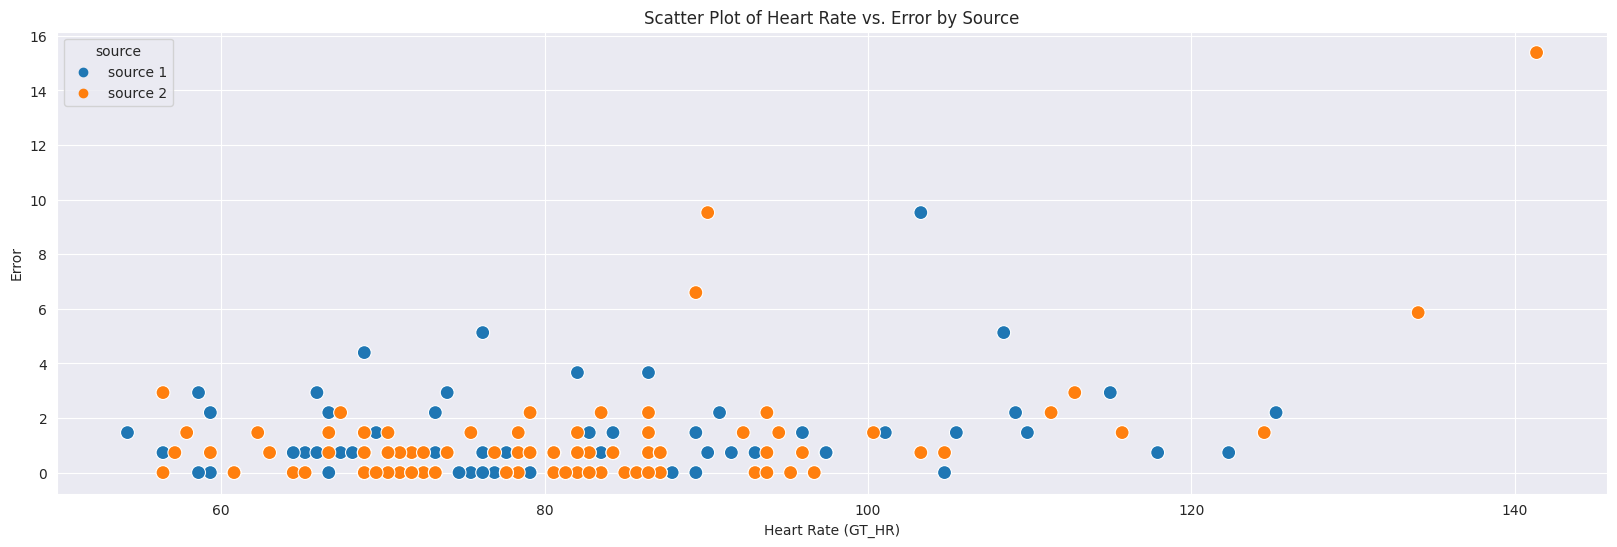

No. of Participants in dataset:  45


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


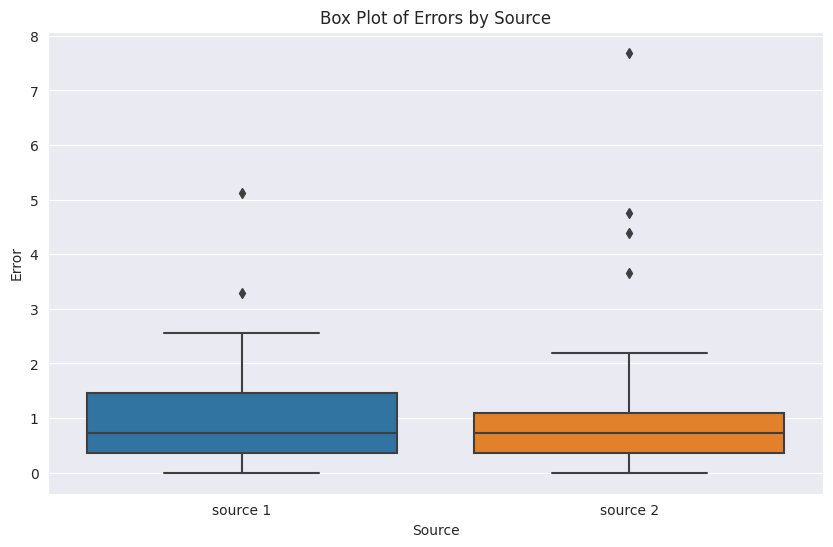

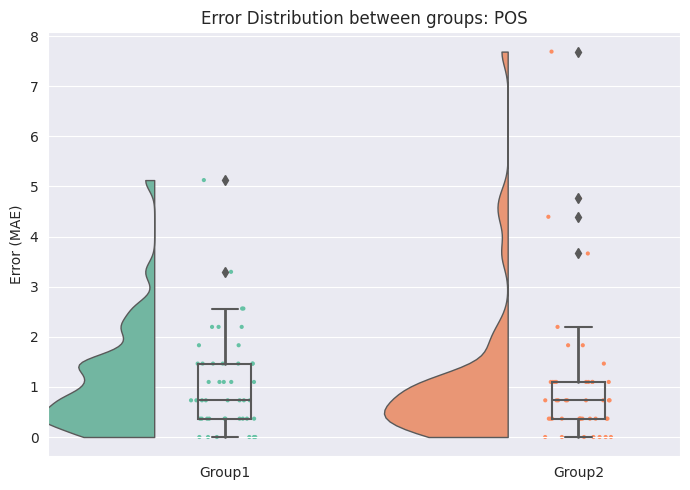

No significant difference detected between scenarios.
GREEN
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


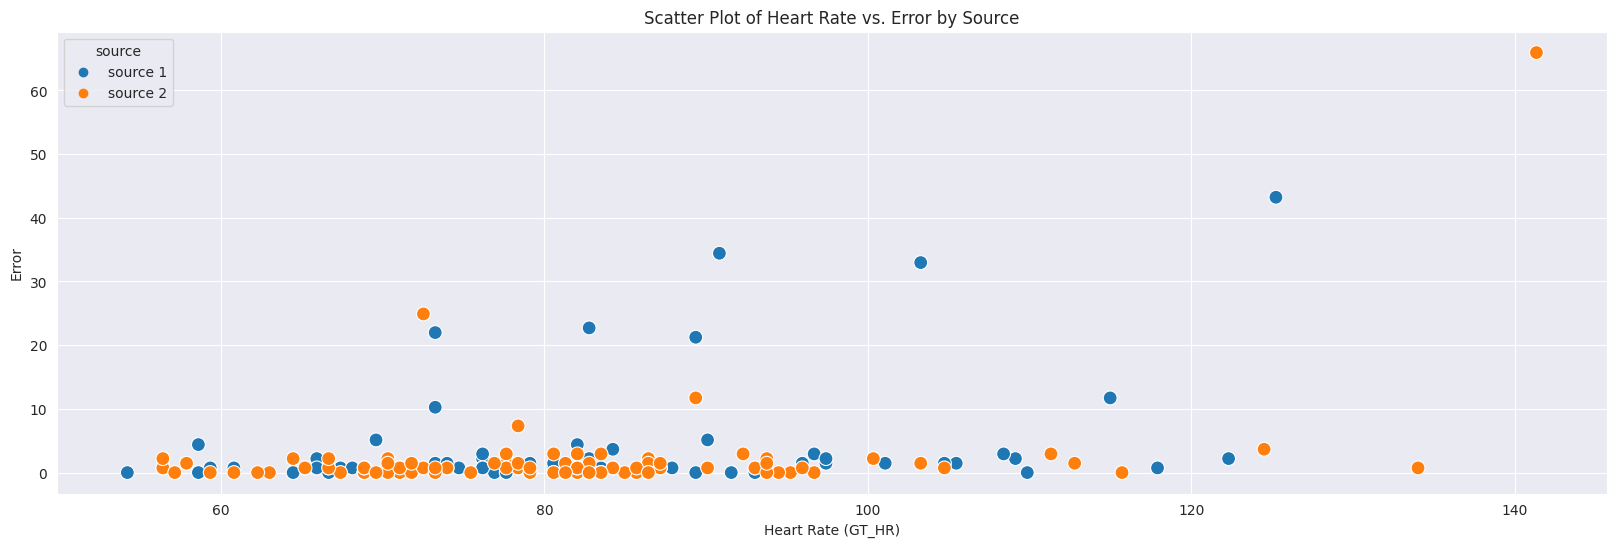

No. of Participants in dataset:  45


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


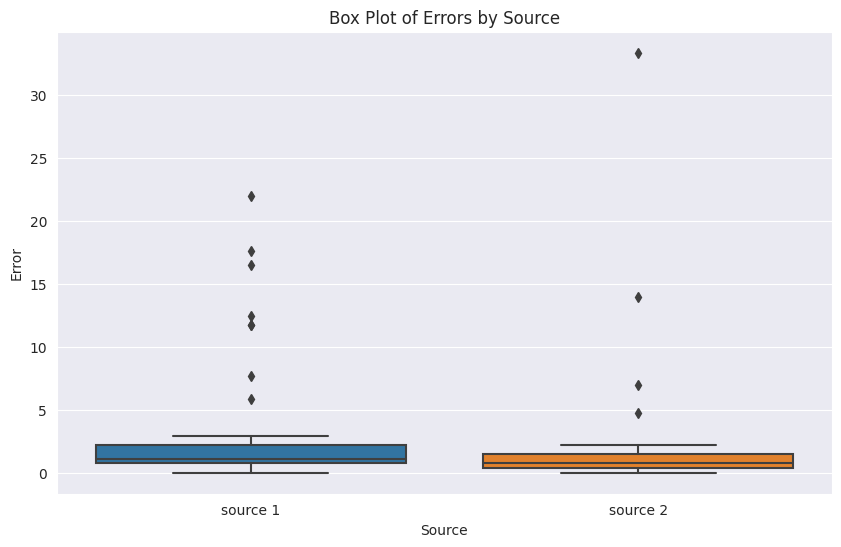

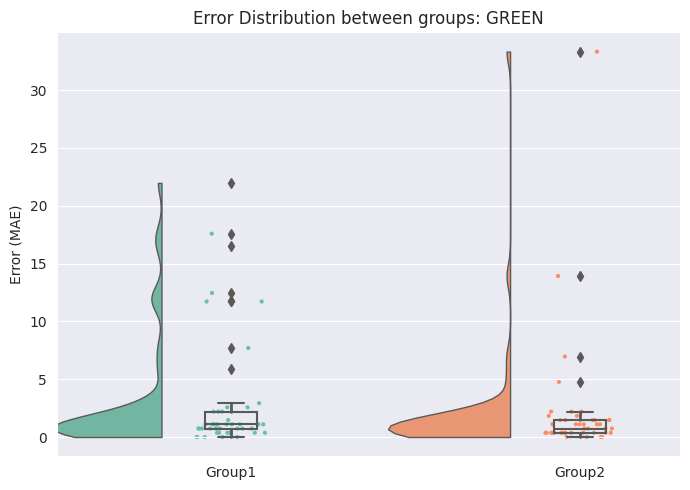

Significant difference detected between scenarios!
ICA
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


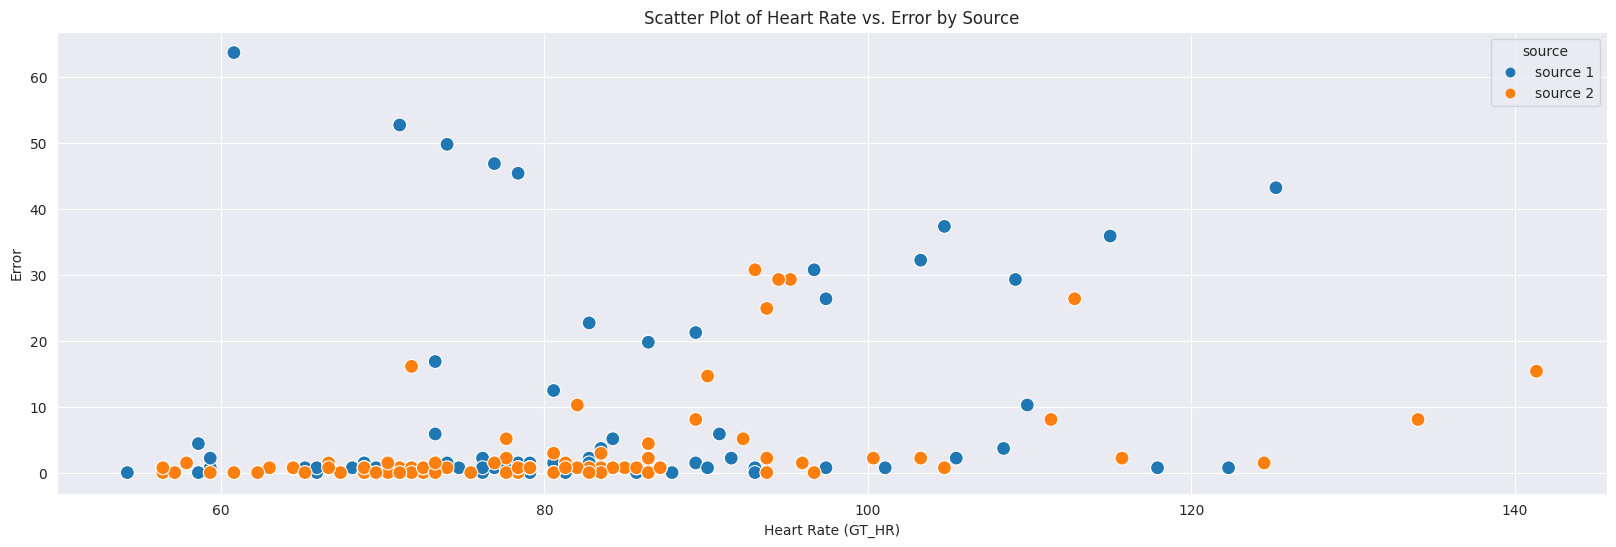

No. of Participants in dataset:  45


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


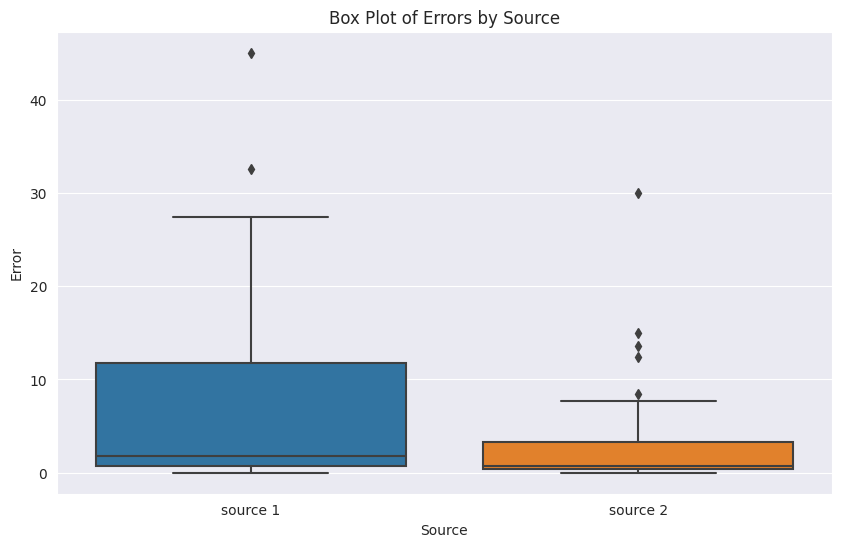

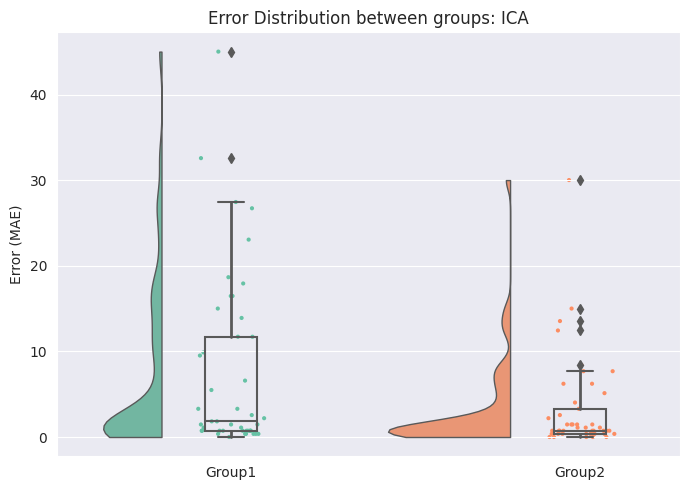

Significant difference detected between scenarios!
CHROM
Using CHILL dataset
Defining scenarios
This is performed on illumination splits


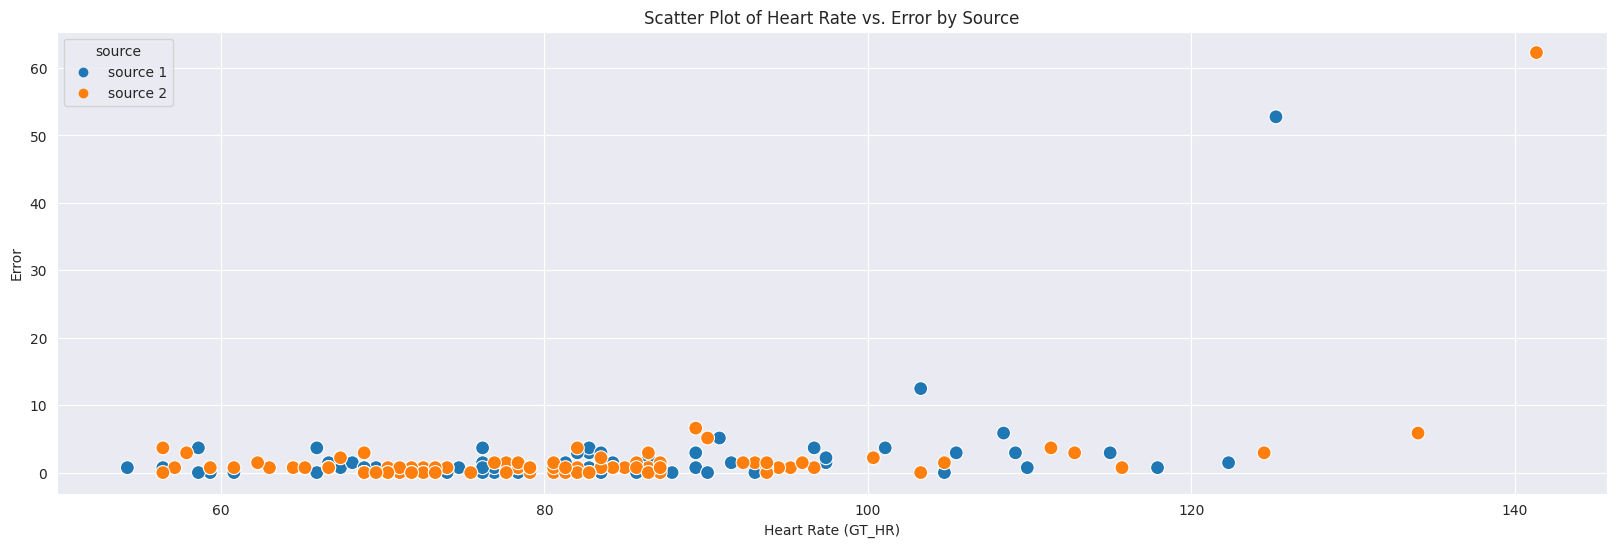

No. of Participants in dataset:  45


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


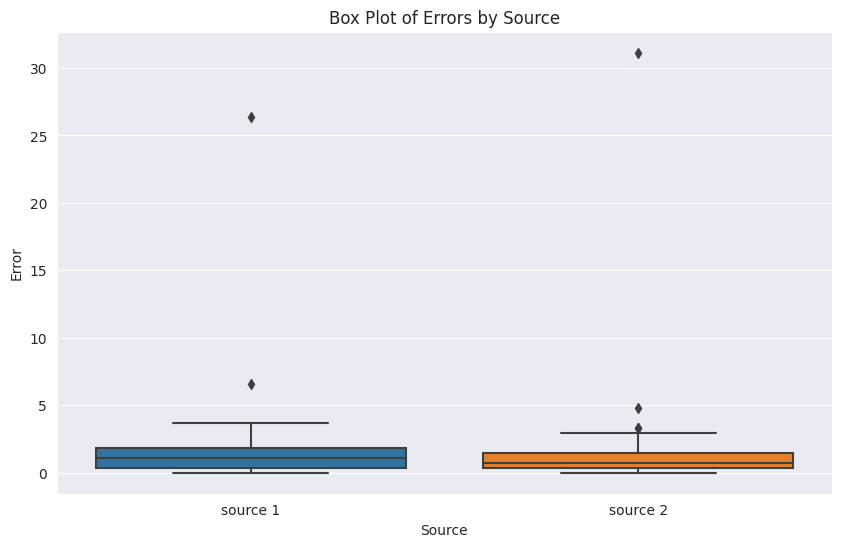

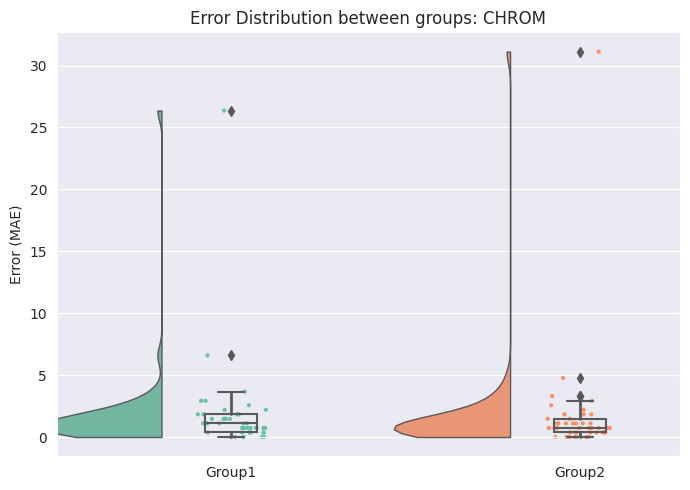

No significant difference detected between scenarios.


,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,POS,Wilcoxon Signed-Rank Test,266.0,0.418583,-0.423186,0.732422,0.732422,0.000000
1,GREEN,Wilcoxon Signed-Rank Test,248.0,0.045495,-0.453474,1.098633,0.732422,0.366211
2,ICA,Wilcoxon Signed-Rank Test,226.0,0.002794,-0.490492,1.831055,0.732422,1.098633
3,CHROM,Wilcoxon Signed-Rank Test,361.5,0.688171,-0.262493,1.098633,0.732422,0.366211


In [44]:
reload(utils)
from utils import *
models = [ POS_CMBP_df, GREEN_CMBP_df, ICA_CMBP_df, CHROM_CMBP_df]
model_names = ["POS", "GREEN", "ICA", "CHROM"]
results_CMBP = []
dataset = "CHILL"
for model, model_name in zip(models, model_names):

    print(model_name)
    chill_statistical_tests = statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_illumination_groups(plot=True))

results_df = pd.DataFrame(results_CMBP)
results_df

POS
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


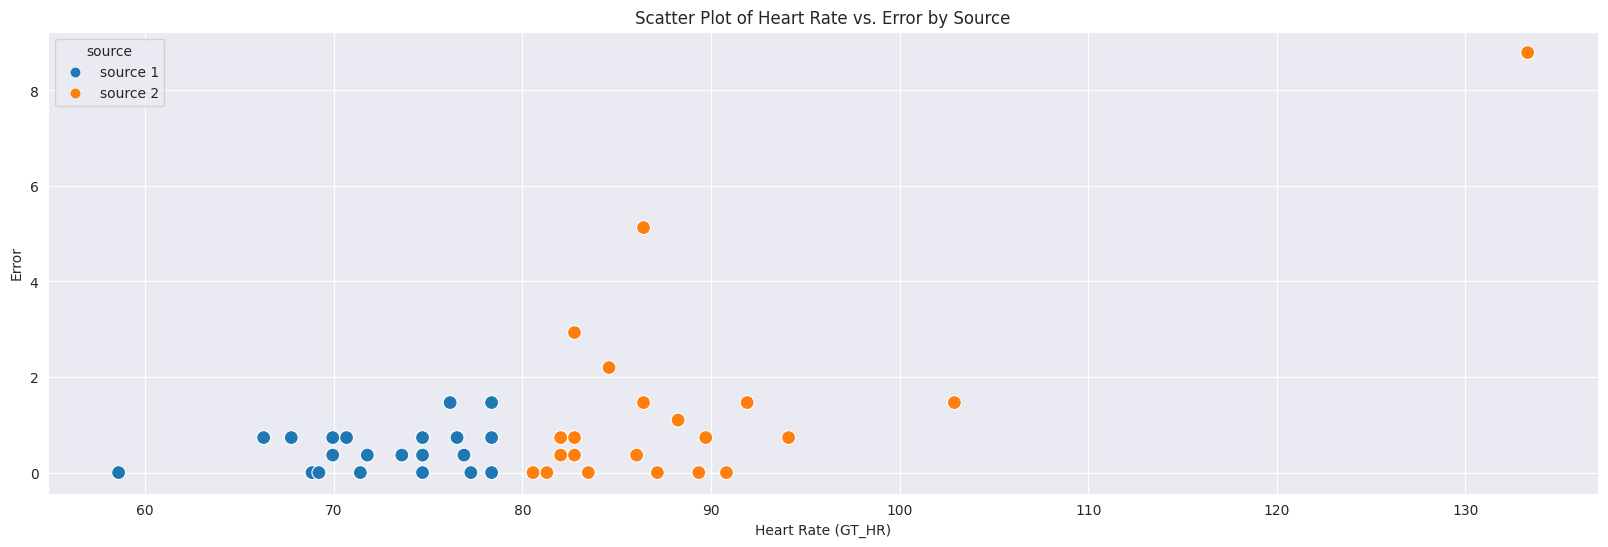

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


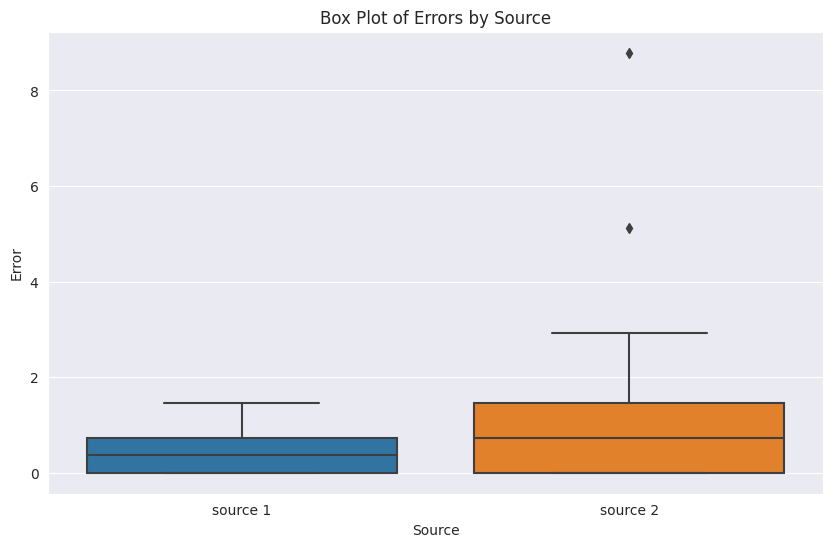

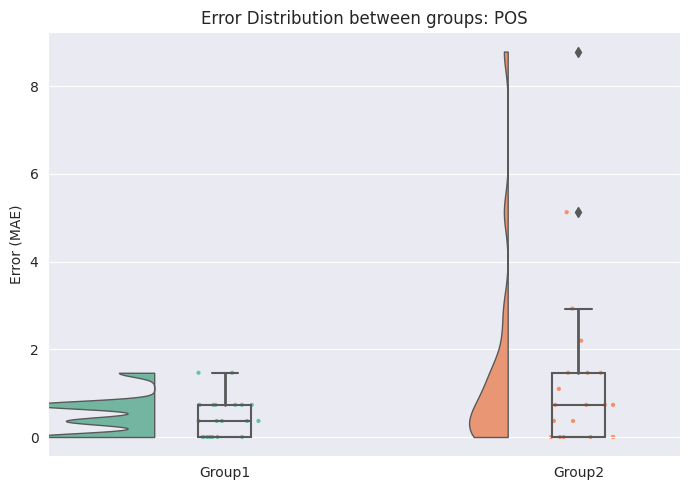

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


No significant difference detected between scenarios.
GREEN
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


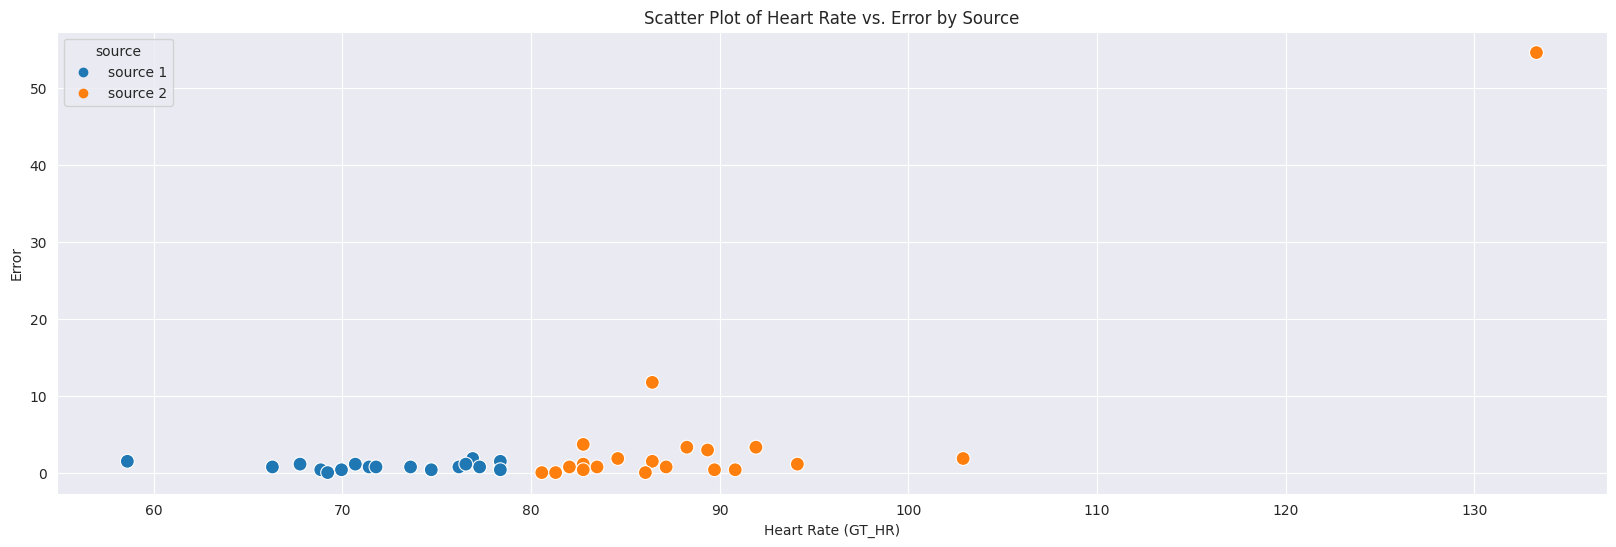

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


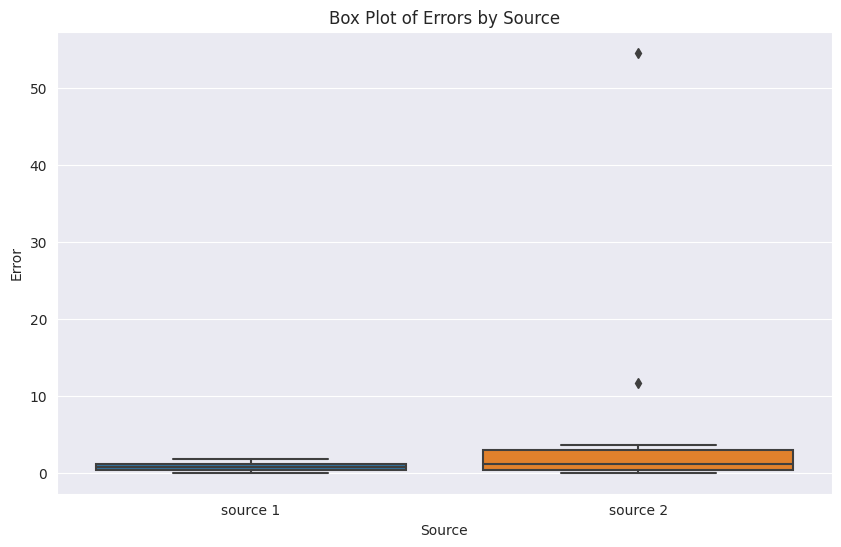

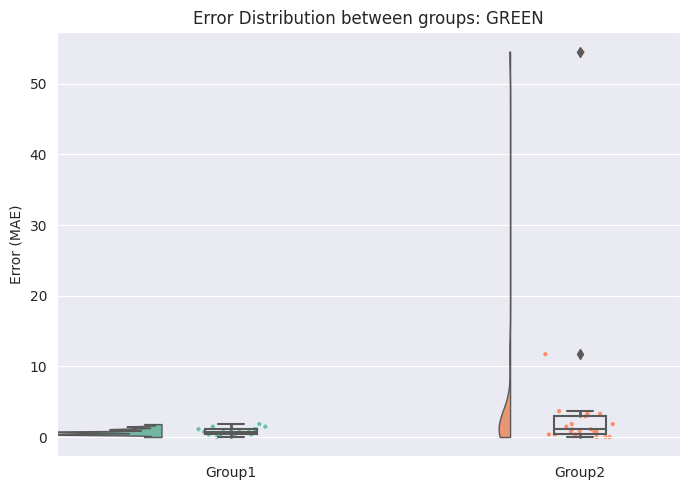

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


Significant difference detected between scenarios!
ICA
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


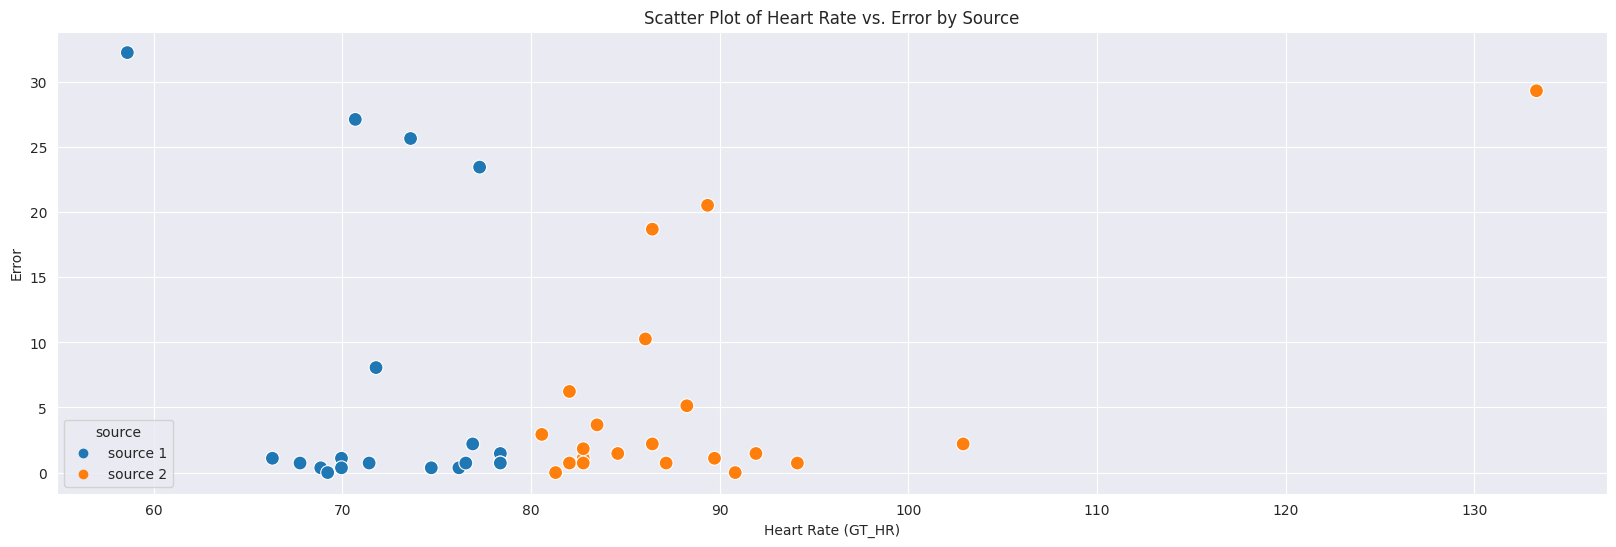

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


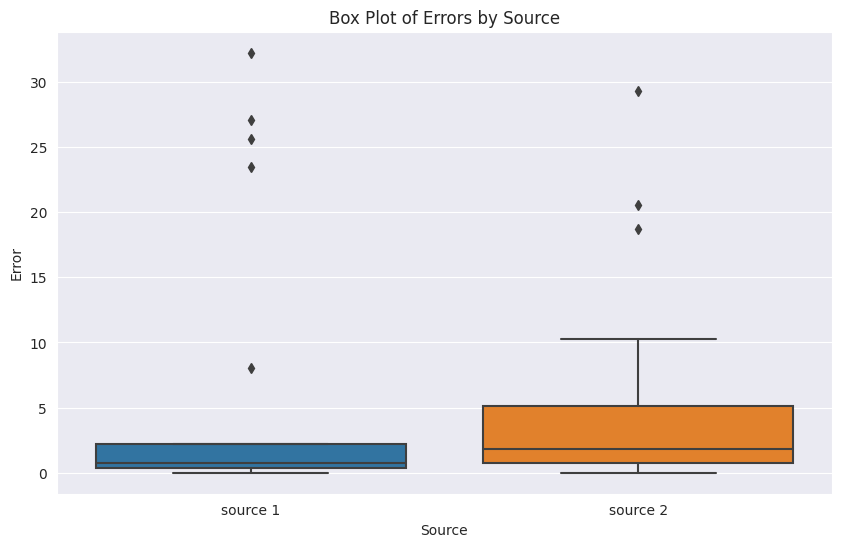

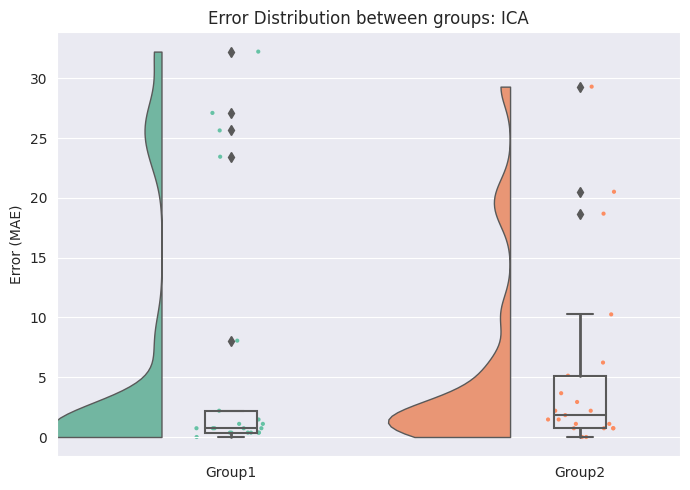

No significant difference detected between scenarios.
CHROM
Using CHILL dataset
Defining scenarios
This is performed on hr splits
No. of Participants in dataset:  21


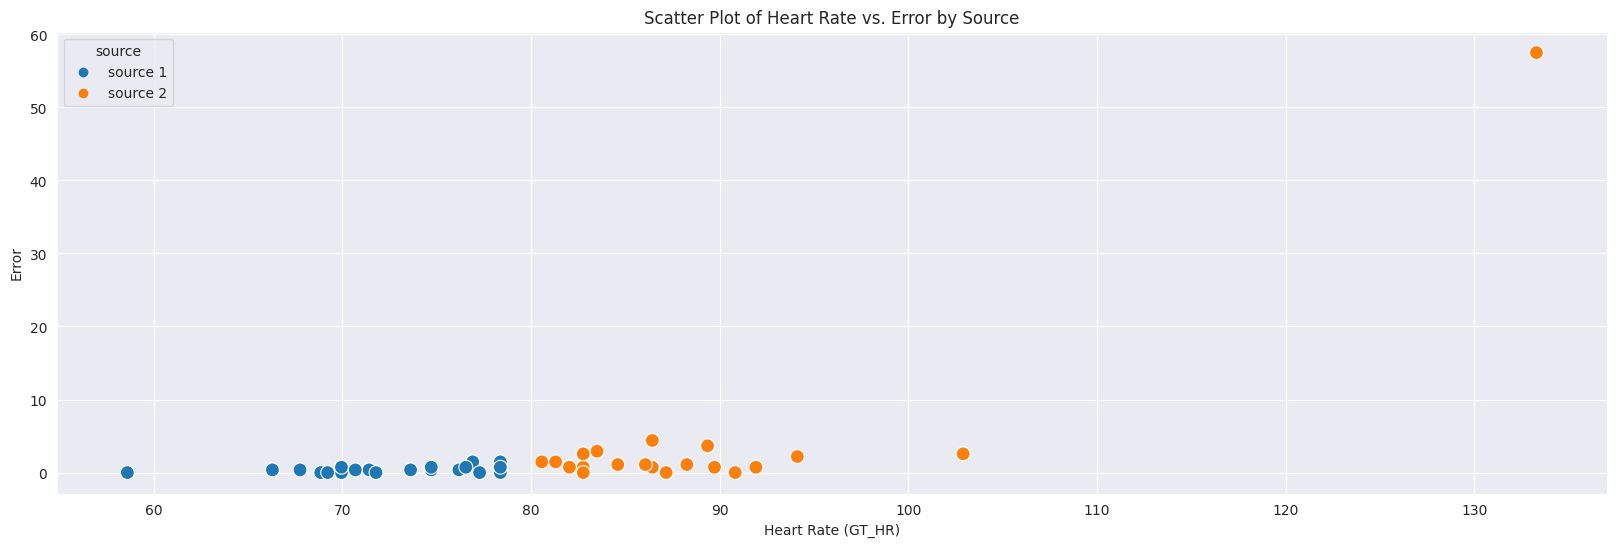

/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/seaborn/categorical.py:82: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_data = [np.asarray(s, float) for k, s in iter_data]


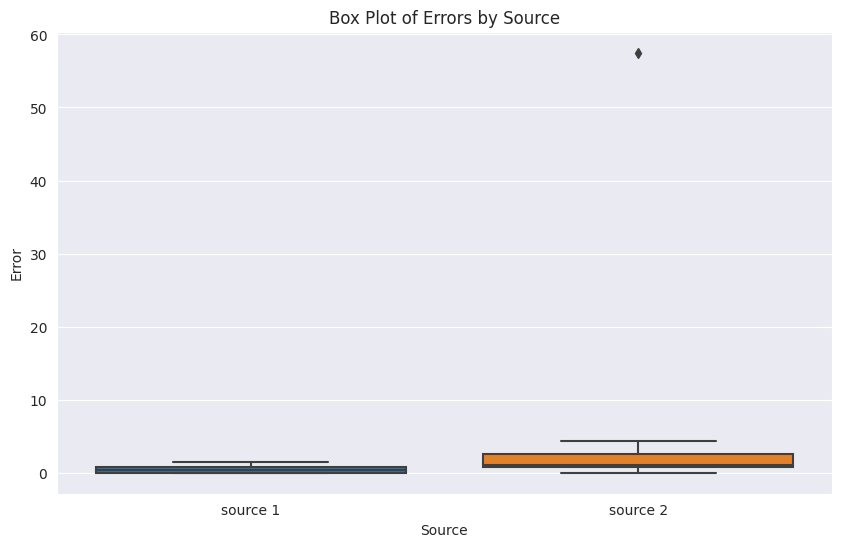

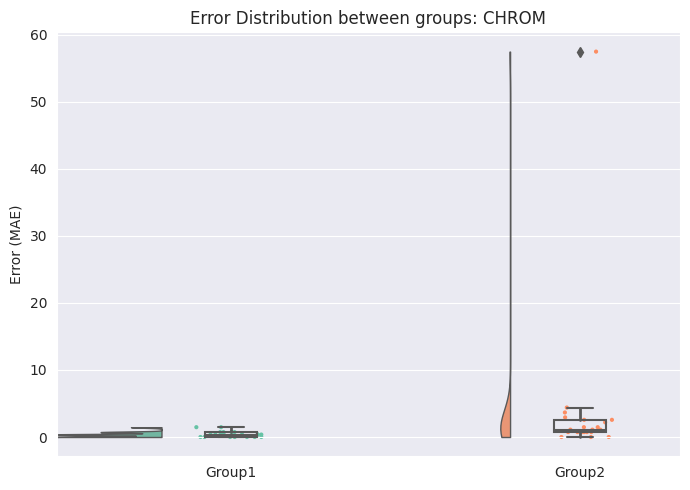

Significant difference detected between scenarios!


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/scipy/stats/morestats.py:2957: UserWarning: Exact p-value calculation does not work if there are ties. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


,model,test_Used,t_statistic,p_value,effect_size_r,median_samples1,median_samples2,delta_median
0,POS,Wilcoxon Signed-Rank Test,35.0,0.085494,-0.610572,0.366211,0.732422,-0.366211
1,GREEN,Wilcoxon Signed-Rank Test,32.0,0.018555,-0.633326,0.732422,1.098633,-0.366211
2,ICA,Wilcoxon Signed-Rank Test,87.5,0.337660,-0.212373,0.732422,1.831055,-1.098633
3,CHROM,Wilcoxon Signed-Rank Test,11.5,0.000723,-0.788813,0.366211,1.098633,-0.732422


In [45]:
results_CMBP = []
dataset = "CHILL"
for model, model_name in zip(models, model_names):

    print(model_name)
    chill_statistical_tests = statistical_tests(model, model_name, dataset)
    results_CMBP.append(chill_statistical_tests.paired_wilcoxen_test_on_hr_groups(plot=True))

results_df = pd.DataFrame(results_CMBP)
results_df

----------------------------------------
POS
defaultdict(<class 'list'>, {})


/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/numpy/core/_methods.py:264: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/homes/bacharya/miniconda3/envs/toolbox/lib/python3.8/site-packages/numpy/core/_methods.py:256: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


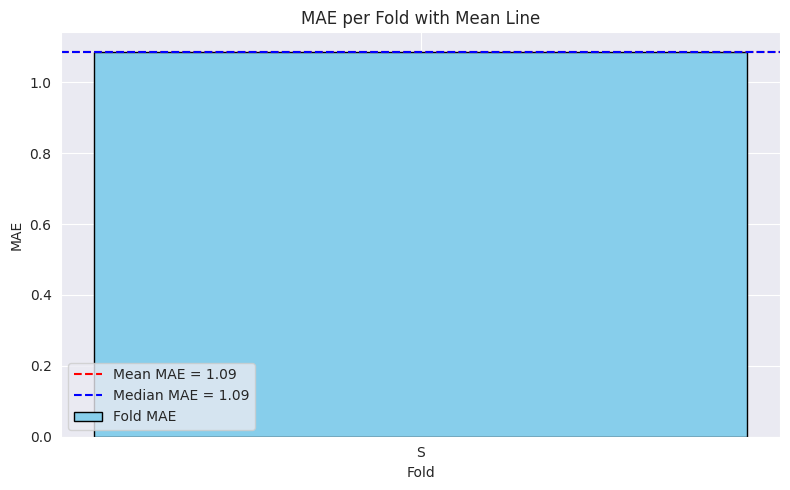

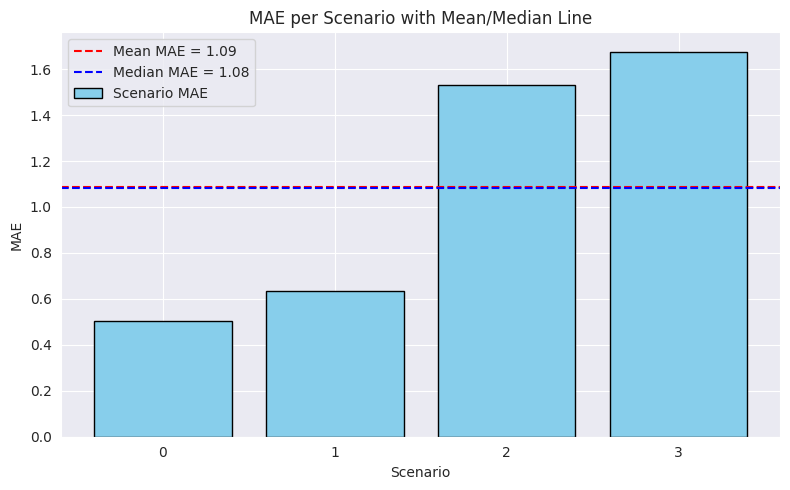


Overall MAE:  1.08642578125

Overall MAE:  1.08642578125
----------------------------------------
GREEN
defaultdict(<class 'list'>, {})


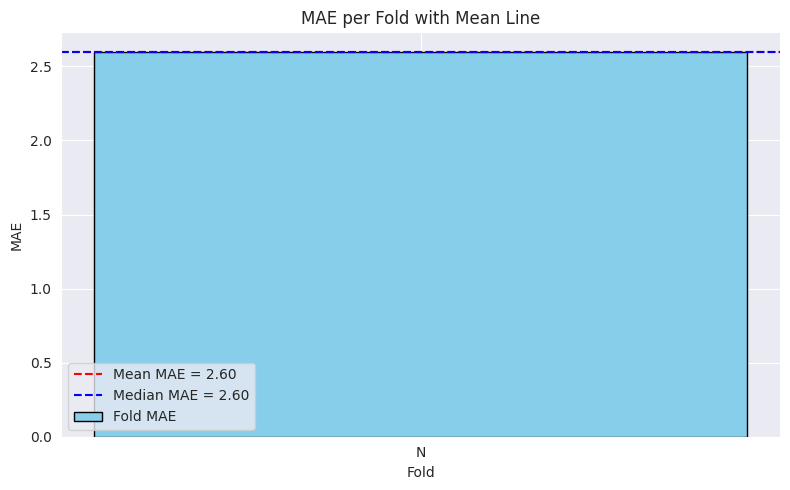

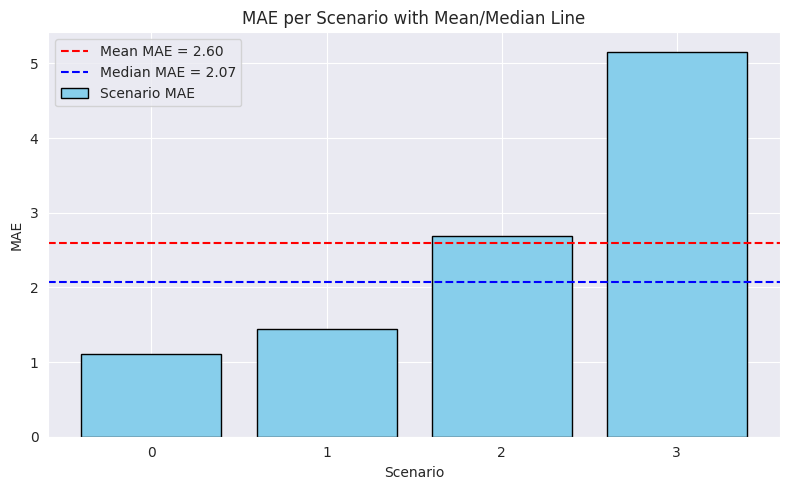


Overall MAE:  2.60009765625

Overall MAE:  2.60009765625
----------------------------------------
CHROM
defaultdict(<class 'list'>, {})


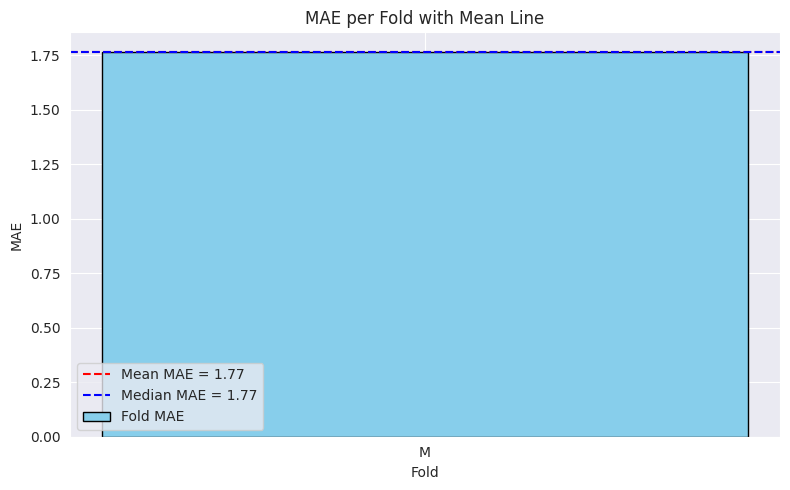

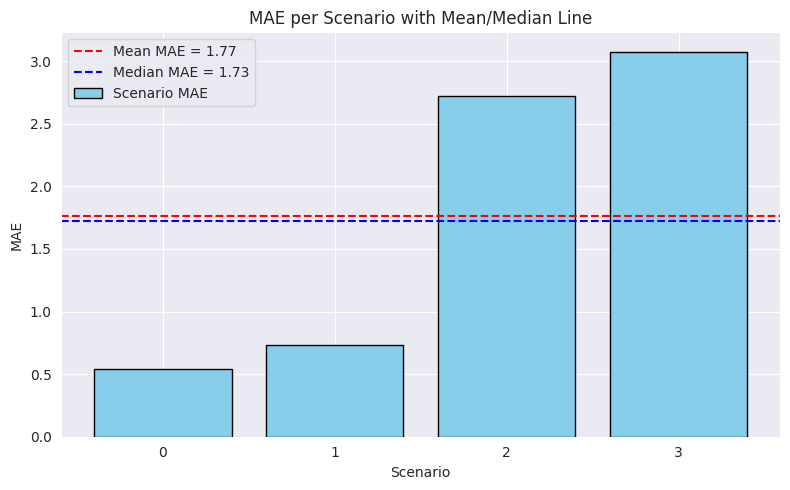


Overall MAE:  1.7659505208333333

Overall MAE:  1.7659505208333335
----------------------------------------
ICA
defaultdict(<class 'list'>, {})


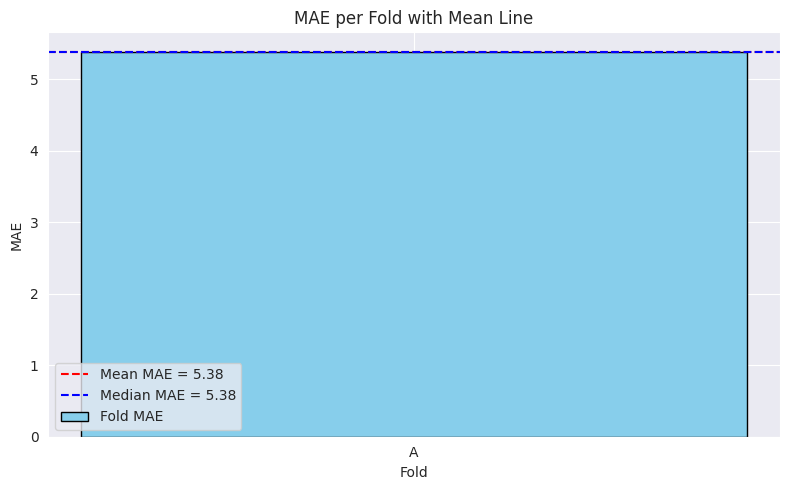

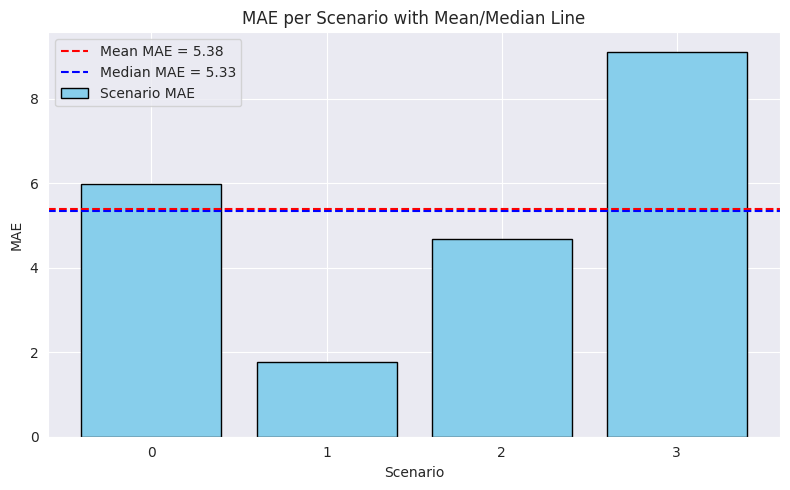


Overall MAE:  5.38330078125

Overall MAE:  5.38330078125
----------------------------------------


In [30]:
# POS CMBP
model_metrics = {}
scenarios_metrics = {}
errors_per_fold_per_scenario = {}
errors_per_fold_per_HR_SPLIT = {}

print("-"*40)
print("POS")
model_metrics['POS'], scenarios_metrics['POS'], errors_per_fold_per_scenario['POS'], errors_per_fold_per_HR_SPLIT['POS'] =  calculate_metrics(CMBP_POS_experiments)
print("-"*40)

print("GREEN")
model_metrics['GREEN'], scenarios_metrics['GREEN'], errors_per_fold_per_scenario['GREEN'], errors_per_fold_per_HR_SPLIT['GREEN'] =  calculate_metrics(CMBP_GREEN_experiments)
print("-"*40)

print("CHROM")
model_metrics['CHROM'], scenarios_metrics['CHROM'], errors_per_fold_per_scenario['CHROM'], errors_per_fold_per_HR_SPLIT['CHROM'] =  calculate_metrics(CMBP_CHROM_experiments)
print("-"*40)

print("ICA")
model_metrics['ICA'], scenarios_metrics['ICA'], errors_per_fold_per_scenario['ICA'], errors_per_fold_per_HR_SPLIT['ICA'] =  calculate_metrics(CMBP_ICA_experiments)
print("-"*40)


<Axes: >

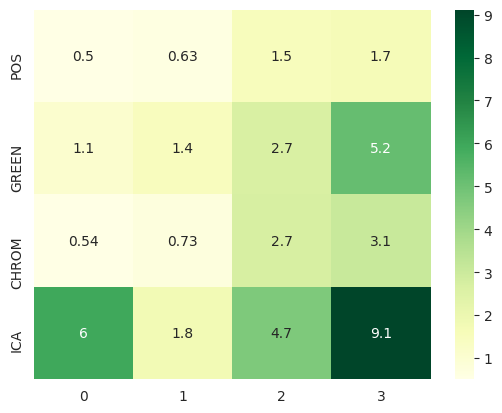

In [31]:
import seaborn as sns
df = pd.DataFrame.from_dict(scenarios_metrics).T
df
sns.heatmap(df, annot=True, cmap='YlGn')

In [32]:
scenarios_metrics

{'POS': defaultdict(list,
             {'0': 0.5045572916666666,
              '1': 0.634765625,
              '2': 1.5299479166666667,
              '3': 1.6764322916666667}),
 'GREEN': defaultdict(list,
             {'0': 1.1067708333333333,
              '1': 1.4485677083333333,
              '2': 2.685546875,
              '3': 5.159505208333333}),
 'CHROM': defaultdict(list,
             {'0': 0.537109375,
              '1': 0.732421875,
              '2': 2.7180989583333335,
              '3': 3.076171875}),
 'ICA': defaultdict(list,
             {'0': 5.973307291666667,
              '1': 1.7578125,
              '2': 4.6875,
              '3': 9.114583333333334})}